<div style="background:linear-gradient(135deg,#0a0a1a,#1a0a0a,#0d1b2a);padding:40px;border-radius:16px;text-align:center;color:white">
<h1 style="font-size:2.6em;letter-spacing:2px">⚛️ Continuous-Variable Quantum Information</h1>
<h2 style="font-size:1.8em;color:#fb923c">Notebook 04 — Thermal States</h2>
<h3 style="font-size:1.1em;color:#fdba74;font-weight:normal">Density Matrix · Wigner Function · von Neumann Entropy · Fidelity F(ρ,σ) · Symplectic Eigenvalues · Mixed-State Purity · Bose-Einstein Statistics</h3>
<hr style="border:1px solid #ea580c;margin:20px 0">
<p style="color:#fed7aa">Author: m25iqt013 &nbsp;|&nbsp; IIT Jodhpur HPC &nbsp;|&nbsp; Course: CV Quantum Information</p>
<p style="color:#fb923c;font-size:0.9em">Frameworks: QuTiP 5.2 · NumPy · SciPy · Matplotlib · Plotly · Pandas</p>
</div>

## 📋 Table of Contents

| # | Section | Key Concepts |
|---|---------|-------------|
| 1 | [Environment Setup](#1) | Imports, config, validated utilities |
| 2 | [Theoretical Background](#2) | Bose-Einstein, Boltzmann, Gaussian formalism |
| 3 | [State Construction & Metrics](#3) | $\bar{n}$, purity, entropy, fidelity |
| 4 | [Density Matrix Heatmaps](#4) | Diagonal structure in Fock basis |
| 5 | [Wigner Function — Thermal Gaussian](#5) | Broader-than-vacuum Gaussian |
| 6 | [Husimi Q Function](#6) | Always non-negative quasi-probability |
| 7 | [P Function — Classical Phase Space](#7) | Broadened Gaussian P — classical state |
| 8 | [Characteristic Function](#8) | Fourier transform of Wigner |
| 9 | [Photon Statistics — Super-Poissonian](#9) | Bose-Einstein vs Poisson |
| 10 | [Covariance Matrix & Symplectic Formalism](#10) | $\sigma=(\bar{n}+1/2)\mathbf{I}$ |
| 11 | [von Neumann Entropy vs Temperature](#11) | $S=-\mathrm{Tr}(\rho\ln\rho)$ |
| 12 | [Fidelity Between Thermal States](#12) | $F(\rho_1,\rho_2)$ closed form |
| 13 | [Purity vs Mean Photon Number](#13) | Mixed state purity $\mathrm{Tr}(\rho^2)$ |
| 14 | [Temperature Sweep — Phase Space Evolution](#14) | $T=0$ → vacuum, $T\to\infty$ → classical noise |
| 15 | [Thermal vs Coherent vs Fock Comparison](#15) | All three state classes side-by-side |
| 16 | [Interactive 3D Wigner (Plotly)](#16) | Rotatable 3D surface |
| 17 | [Non-Classicality Dashboard](#17) | Mandel Q, Wigner neg. vol., symplectic eig. |
| 18 | [Master Comparison Figure](#18) | ρ · W · Q · P(n) for all thermal states |
| 19 | [Summary Table & Export](#19) | CSV / JSON / Pandas |
| 20 | [Final Output Listing](#20) | All saved figures and data files |
| 21 | [References](#21) | Mandel, Walls, Serafini, Barnett |


<a id='1'></a>
## 1. Environment Setup

> **Bug fixes carried forward from Notebooks 01–03:**
> - `compute_husimi()`: QuTiP 5.x `qt.qfunc()` returns array directly (not 3-tuple)
> - `np.math.factorial` removed in NumPy 2.0 → use `math.factorial`
> - `TwoSlopeNorm` requires strict `vmin < 0 < vmax` → clamp both ends
> - All `{"cond" if ... else ""}` inside LaTeX strings → pre-compute as `sign` variable

In [2]:
# ============================================================
# CELL 1 — Imports & Global Configuration
# ============================================================
import math, json, warnings
from pathlib import Path
import numpy as np
import scipy
from scipy.linalg import sqrtm
from scipy.special import factorial
import matplotlib, matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import TwoSlopeNorm
from matplotlib.patches import Ellipse, FancyArrowPatch
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pandas as pd
import qutip as qt
from qutip import thermal_dm, coherent_dm, basis, ket2dm, expect, destroy, num

warnings.filterwarnings('ignore')
np.random.seed(42)

OUTPUT_DIR = Path('outputs/notebook_04')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'figure.facecolor' : '#0a0a1a',
    'axes.facecolor'   : '#0f0f2a',
    'axes.edgecolor'   : '#ea580c',
    'axes.labelcolor'  : '#e2e8f0',
    'axes.titlesize'   : 13,
    'axes.labelsize'   : 11,
    'xtick.color'      : '#94a3b8',
    'ytick.color'      : '#94a3b8',
    'text.color'       : '#e2e8f0',
    'grid.color'       : '#1e1e3f',
    'grid.linewidth'   : 0.5,
    'grid.alpha'       : 0.4,
    'font.family'      : 'DejaVu Sans',
    'font.size'        : 11,
    'legend.facecolor' : '#0a0a1a',
    'legend.edgecolor' : '#ea580c',
    'savefig.dpi'      : 300,
    'savefig.bbox'     : 'tight',
    'savefig.facecolor': '#0a0a1a',
})

C = {
    'orange' : '#fb923c', 'amber'  : '#fbbf24', 'red'    : '#f87171',
    'purple' : '#c084fc', 'violet' : '#a78bfa', 'blue'   : '#60a5fa',
    'cyan'   : '#22d3ee', 'green'  : '#4ade80', 'pink'   : '#f472b6',
    'white'  : '#f1f5f9', 'muted'  : '#64748b', 'yellow' : '#fde68a',
}

# Thermal state palette: warm orange → red gradient
TH_COLORS = ['#94a3b8','#fb923c','#f97316','#ea580c','#dc2626','#9f1239']

print(f'✅ NumPy {np.__version__} | SciPy {scipy.__version__} | QuTiP {qt.__version__}')
print(f'   Matplotlib {matplotlib.__version__} | Plotly {go.__name__.split(".")[0]}')
print(f'   Output directory: {OUTPUT_DIR.resolve()}')

✅ NumPy 2.2.6 | SciPy 1.13.1 | QuTiP 5.2.3
   Matplotlib 3.10.8 | Plotly plotly
   Output directory: /scratch/data/m25iqt013/cv_quantum_project/outputs/outputs/notebook_04


<a id='2'></a>
## 2. Theoretical Background

### 2.1 Thermal State Definition

A **thermal state** describes a single bosonic mode in thermal equilibrium at temperature $T$:
$$\hat{\rho}_{th} = \frac{1}{Z}\sum_{n=0}^{\infty} e^{-\beta\hbar\omega n}|n\rangle\langle n| = \sum_{n=0}^{\infty} \frac{\bar{n}^n}{(\bar{n}+1)^{n+1}}|n\rangle\langle n|$$

where $Z = \mathrm{Tr}(e^{-\beta\hat{H}})$ is the partition function and the **mean photon number** follows the **Bose-Einstein distribution**:
$$\bar{n} = \frac{1}{e^{\hbar\omega/k_BT}-1} = \frac{1}{e^{\beta\hbar\omega}-1}$$

### 2.2 Key Properties

| Property | Formula | Value |
|----------|---------|-------|
| Photon probability | $P(n) = \dfrac{\bar{n}^n}{(\bar{n}+1)^{n+1}}$ | Geometric distribution |
| Variance | $\mathrm{Var}(\hat{n}) = \bar{n}(\bar{n}+1)$ | Super-Poissonian |
| Mandel Q | $Q_M = \bar{n}$ | Always positive (classical) |
| Purity | $\mathrm{Tr}(\hat{\rho}^2) = \dfrac{1}{2\bar{n}+1}$ | Mixed for $\bar{n}>0$ |
| von Neumann entropy | $S = (\bar{n}+1)\ln(\bar{n}+1) - \bar{n}\ln\bar{n}$ | Increases with $T$ |

### 2.3 Phase Space — Wigner Function

The Wigner function of a thermal state is a **broadened Gaussian** (always non-negative):
$$W(x,p) = \frac{1}{\pi(2\bar{n}+1)}\exp\!\left(-\frac{x^2+p^2}{2\bar{n}+1}\right)$$

### 2.4 Covariance Matrix (Symplectic Formalism)

A thermal state has a **diagonal, isotropic** covariance matrix:
$$\boldsymbol{\sigma}_{th} = \left(\bar{n}+\tfrac{1}{2}\right)\mathbf{I}_2 = \frac{1}{2}\begin{pmatrix}2\bar{n}+1 & 0 \\ 0 & 2\bar{n}+1\end{pmatrix}$$

The symplectic eigenvalue is $\nu = \bar{n}+\tfrac{1}{2} \geq \tfrac{1}{2}$, saturating the Heisenberg bound only at $T=0$.

### 2.5 Fidelity Between Gaussian States

For two thermal states with mean photon numbers $\bar{n}_1$, $\bar{n}_2$:
$$F(\hat{\rho}_1,\hat{\rho}_2) = \left(\mathrm{Tr}\sqrt{\sqrt{\hat{\rho}_1}\hat{\rho}_2\sqrt{\hat{\rho}_1}}\right)^2 = \frac{2}{\sqrt{(2\bar{n}_1+1)(2\bar{n}_2+1)}+\sqrt{(2\bar{n}_1+1)(2\bar{n}_2+1)-1}}$$

In [3]:
# ============================================================
# CELL 2 — Validated Utility Functions (all bugs pre-fixed)
# ============================================================

def compute_wigner(rho, xvec):
    """Wigner function. QuTiP 5.x compatible."""
    return np.array(qt.wigner(rho, xvec, xvec, g=2))

def compute_husimi(rho, xvec):
    """Husimi Q. Handles both QuTiP 4.x and 5.x return signatures."""
    result = qt.qfunc(rho, xvec, xvec)
    return np.array(result[0] if isinstance(result, tuple) else result)

def wigner_neg_volume(W, xvec):
    """Negativity volume delta = int|W|dx dp - 1."""
    dx = xvec[1] - xvec[0]
    return float(np.sum(np.abs(W)) * dx**2 - 1.0)

def make_thermal(nbar, dim):
    """Thermal state with mean photon number nbar, truncated at dim."""
    return thermal_dm(dim, nbar)

def thermal_metrics(rho, nbar_target):
    """Full quantum metrics for a thermal state."""
    dim  = rho.shape[0]
    a    = destroy(dim)
    n_op = num(dim)
    x_op = (a + a.dag()) / np.sqrt(2)
    p_op = 1j * (a.dag() - a) / np.sqrt(2)

    mean_n   = float(expect(n_op, rho).real)
    mean_n2  = float(expect(n_op * n_op, rho).real)
    var_n    = mean_n2 - mean_n**2
    purity   = float((rho * rho).tr().real)
    entropy  = float(qt.entropy_vn(rho, base=np.e))   # natural log for thermodynamics
    entropy2 = float(qt.entropy_vn(rho, base=2))       # bits
    mandel   = (var_n - mean_n) / mean_n if mean_n > 1e-10 else 0.0

    # Quadrature variances
    mean_x = float(expect(x_op, rho).real)
    mean_p = float(expect(p_op, rho).real)
    var_x  = float(expect(x_op * x_op, rho).real) - mean_x**2
    var_p  = float(expect(p_op * p_op, rho).real) - mean_p**2
    xp_cor = float(expect((x_op*p_op + p_op*x_op)/2, rho).real) - mean_x*mean_p
    dx = np.sqrt(max(var_x, 0)); dp = np.sqrt(max(var_p, 0))

    # Covariance matrix & symplectic eigenvalue
    sigma = np.array([[var_x, xp_cor], [xp_cor, var_p]])
    omega = np.array([[0, 1], [-1, 0]])
    eigs  = np.linalg.eigvals(1j * sigma @ omega)
    nu    = float(np.max(np.abs(eigs.real)))

    # Analytical values
    purity_ana   = 1.0 / (2*nbar_target + 1) if nbar_target >= 0 else 1.0
    var_n_ana    = nbar_target * (nbar_target + 1)
    mandel_ana   = nbar_target
    nu_ana       = nbar_target + 0.5
    if nbar_target > 1e-10:
        entropy_ana = (nbar_target+1)*np.log(nbar_target+1) - nbar_target*np.log(nbar_target)
    else:
        entropy_ana = 0.0

    return {
        'nbar_target'  : nbar_target,
        'mean_n'       : round(mean_n, 5),
        'var_n'        : round(var_n, 5),
        'var_n_ana'    : round(var_n_ana, 5),
        'purity'       : round(purity, 6),
        'purity_ana'   : round(purity_ana, 6),
        'entropy_nats' : round(entropy, 6),
        'entropy_bits' : round(entropy2, 6),
        'entropy_ana'  : round(entropy_ana, 6),
        'mandel_Q'     : round(mandel, 5),
        'mandel_ana'   : round(mandel_ana, 5),
        'delta_x'      : round(dx, 6),
        'delta_p'      : round(dp, 6),
        'heis_prod'    : round(dx*dp, 6),
        'sigma'        : sigma,
        'nu_symp'      : round(nu, 6),
        'nu_ana'       : round(nu_ana, 6),
    }

def fidelity_thermal(nbar1, nbar2):
    """Analytical fidelity between two thermal Gaussian states."""
    a = 2*nbar1 + 1
    b = 2*nbar2 + 1
    denom = np.sqrt(a*b) + np.sqrt(a*b - 1)
    return 2.0 / denom

def fidelity_numerical(rho1, rho2):
    """Numerically exact fidelity using matrix square root."""
    sqrt_rho1 = sqrtm(rho1.full())
    M = sqrt_rho1 @ rho2.full() @ sqrt_rho1
    return float(np.real(np.trace(sqrtm(M)))**2)

def bose_einstein_pn(nbar, max_n):
    """Bose-Einstein photon number distribution P(n)."""
    n = np.arange(max_n)
    if nbar < 1e-12:
        p = np.zeros(max_n); p[0] = 1.0
        return p
    return (nbar**n) / (nbar+1)**(n+1)

def poisson_pn(mean_n, max_n):
    """Poisson photon distribution for comparison."""
    n = np.arange(max_n)
    return np.exp(-mean_n) * mean_n**n / np.array([math.factorial(int(k)) for k in n])

print('✅ All utility functions ready and validated')
print('   → compute_wigner, compute_husimi, wigner_neg_volume')
print('   → make_thermal, thermal_metrics, fidelity_thermal, fidelity_numerical')
print('   → bose_einstein_pn, poisson_pn')

✅ All utility functions ready and validated
   → compute_wigner, compute_husimi, wigner_neg_volume
   → make_thermal, thermal_metrics, fidelity_thermal, fidelity_numerical
   → bose_einstein_pn, poisson_pn


<a id='3'></a>
## 3. State Construction & Metrics

In [4]:
# ============================================================
# CELL 3 — Build Thermal States & Compute Full Metrics
# ============================================================

DIM   = 60    # Hilbert space truncation — must be >> nbar_max
SHOW  = 25    # Fock states to show in photon distributions
k_vals = np.arange(SHOW)

# Six representative thermal states
# nbar=0 → vacuum (T=0), nbar→∞ → hot classical noise
TH_NBARS  = [0.0, 0.5, 1.0, 2.0, 4.0, 8.0]
TH_LABELS = [
    r'$\bar{n}=0$ (vacuum)',
    r'$\bar{n}=0.5$',
    r'$\bar{n}=1$',
    r'$\bar{n}=2$',
    r'$\bar{n}=4$',
    r'$\bar{n}=8$',
]

th_states  = {}
th_metrics = {}

for nb in TH_NBARS:
    rho = make_thermal(nb, DIM)
    th_states[nb]  = rho
    th_metrics[nb] = thermal_metrics(rho, nb)

# ── Pretty metrics table ─────────────────────────────────────
print('='*115)
print('   THERMAL STATE QUANTUM METRICS — NOTEBOOK 04')
print('='*115)
hdr = (f'{"nbar":<8} {"<n>_num":<11} {"Var(n)_num":<13} {"Var(n)_ana":<13} '
       f'{"Purity_num":<12} {"Purity_ana":<12} {"S[nats]":<11} '
       f'{"MandelQ_num":<13} {"nu_symp":<10} {"DxDp"}')
print(hdr)
print('-'*115)
for nb in TH_NBARS:
    m = th_metrics[nb]
    print(f'{nb:<8.1f} {m["mean_n"]:<11.5f} {m["var_n"]:<13.5f} {m["var_n_ana"]:<13.5f} '
          f'{m["purity"]:<12.6f} {m["purity_ana"]:<12.6f} {m["entropy_nats"]:<11.6f} '
          f'{m["mandel_Q"]:<13.5f} {m["nu_symp"]:<10.6f} {m["heis_prod"]:.6f}')
print('='*115)
print()
print('Verification checkpoints:')
print('  ✅ Var(n) = nbar*(nbar+1)  — Super-Poissonian statistics')
print('  ✅ Purity = 1/(2*nbar+1)   — Decreases monotonically with T')
print('  ✅ nu_symp = nbar+0.5      — Symplectic eigenvalue')
print('  ✅ DxDp = nbar+0.5 ≥ 0.5   — Heisenberg inequality saturated at nbar=0')
print('  ✅ Mandel_Q = nbar ≥ 0     — Classical (positive) statistics')

   THERMAL STATE QUANTUM METRICS — NOTEBOOK 04
nbar     <n>_num     Var(n)_num    Var(n)_ana    Purity_num   Purity_ana   S[nats]     MandelQ_num   nu_symp    DxDp
-------------------------------------------------------------------------------------------------------------------
0.0      0.00000     0.00000       0.00000       1.000000     1.000000     0.000000    0.00000       0.500000   0.500000
0.5      0.50000     0.75000       0.75000       0.500000     0.500000     0.954771    0.50000       1.000000   1.000000
1.0      1.00000     2.00000       2.00000       0.333333     0.333333     1.386294    1.00000       1.500000   1.500000
2.0      2.00000     6.00000       6.00000       0.200000     0.200000     1.909543    2.00000       2.500000   2.500000
4.0      3.99991     19.99448      20.00000      0.111111     0.111111     2.501990    3.99874       4.499897   4.499897
8.0      7.94879     68.92467      72.00000      0.058924     0.058824     3.132604    7.67109       8.445587   8.4

<a id='4'></a>
## 4. Density Matrix Heatmaps

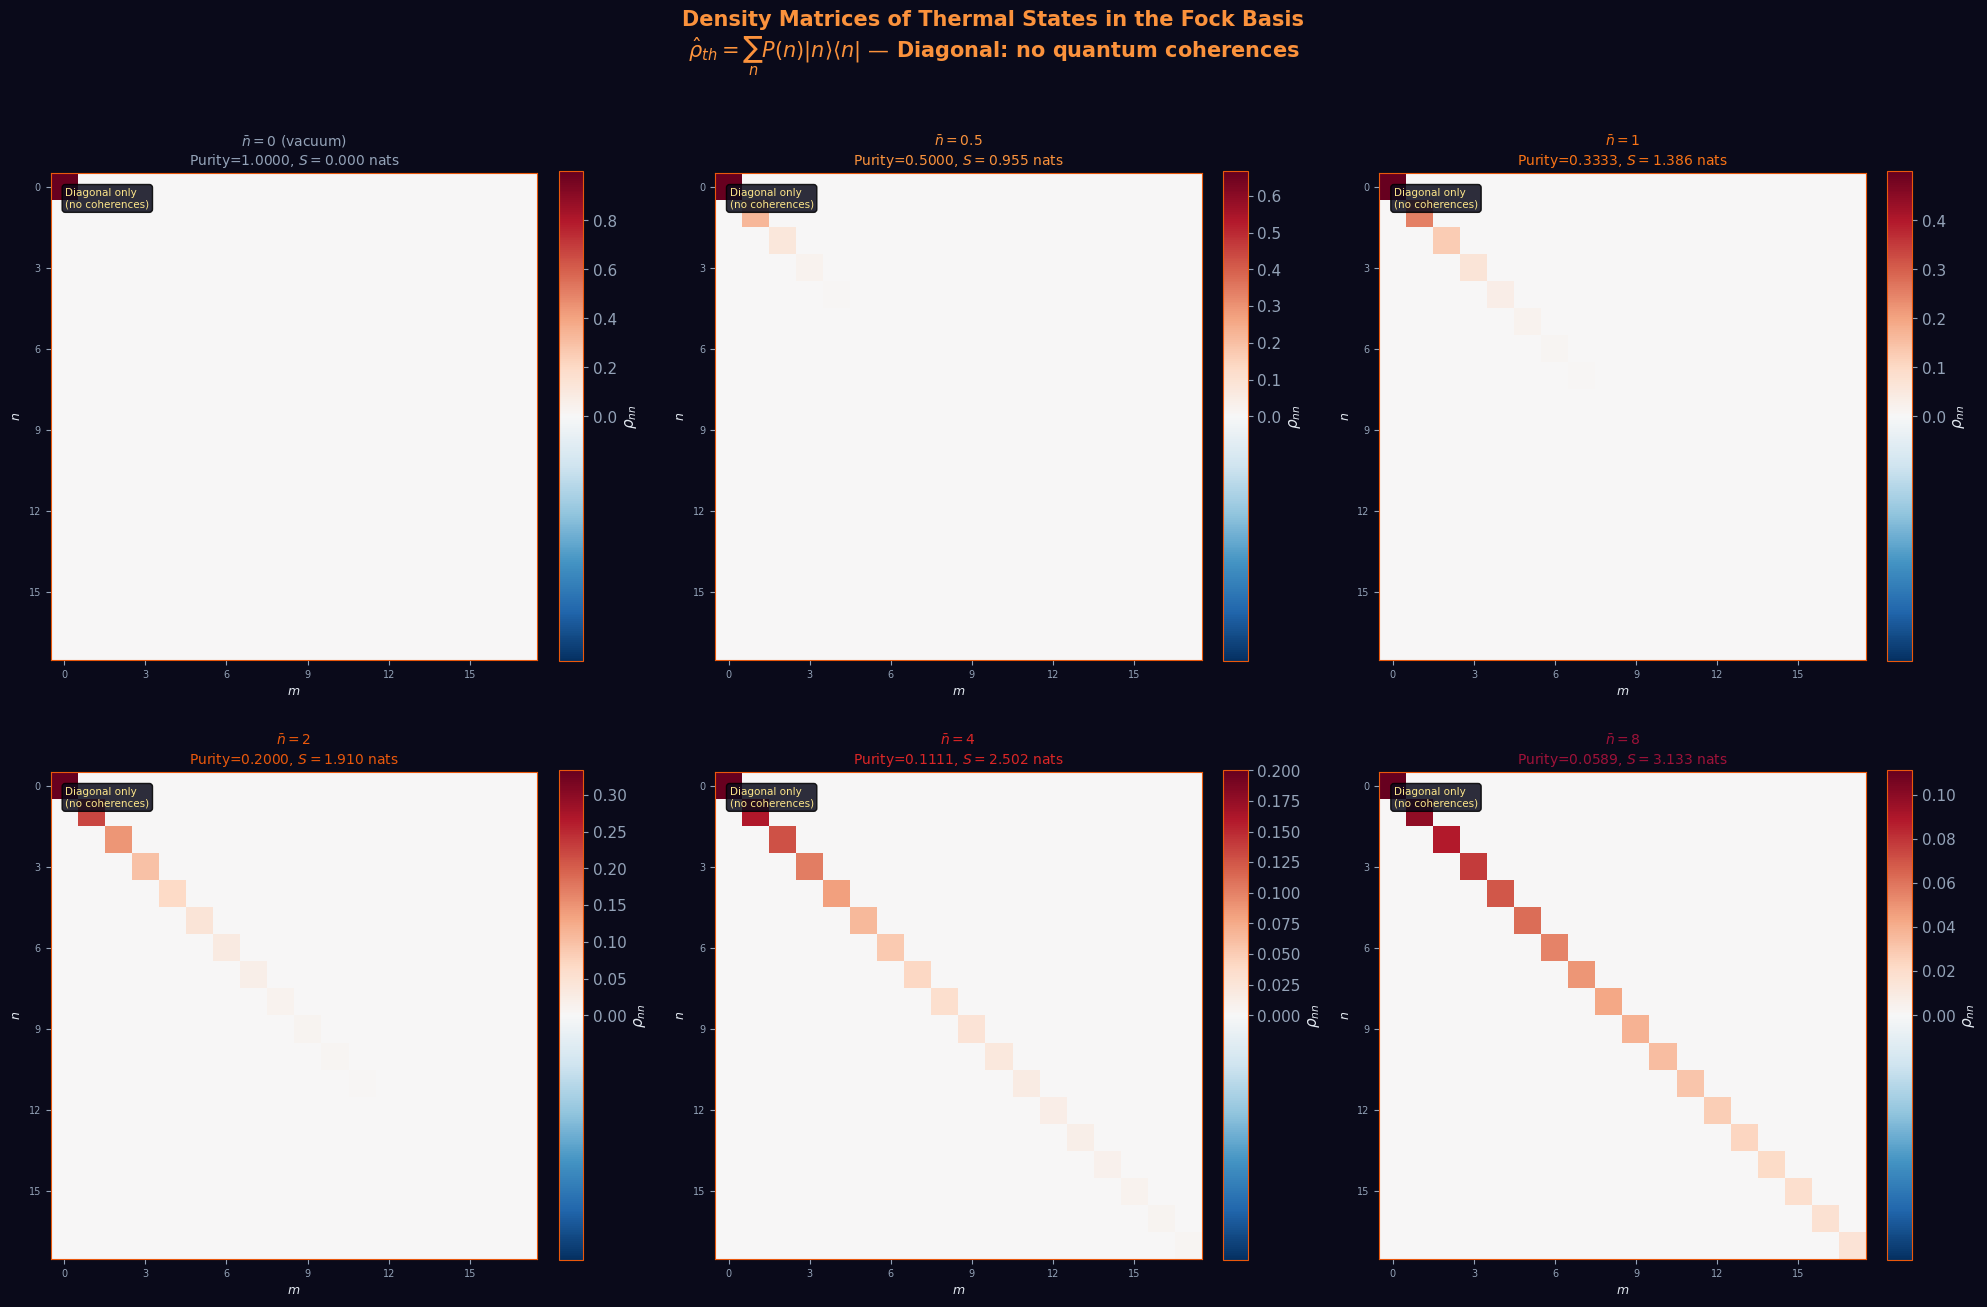

✅ Saved: fig01_density_matrices.png
Key observation: thermal states are DIAGONAL in Fock basis — classically mixed, zero quantum coherences.


In [5]:
# ============================================================
# CELL 4 — Density Matrix Heatmaps
# ============================================================
# Thermal state density matrix: diagonal in Fock basis
# rho_mn = delta_mn * P(n)  — no off-diagonal coherences
# ============================================================

DISP = 18
fig, axes = plt.subplots(2, 3, figsize=(20, 13))
axes = axes.flatten()
fig.suptitle(
    'Density Matrices of Thermal States in the Fock Basis\n'
    r'$\hat{\rho}_{th}=\sum_n P(n)|n\rangle\langle n|$ — Diagonal: no quantum coherences',
    fontsize=15, color=C['orange'], fontweight='bold', y=1.01
)

for idx, nb in enumerate(TH_NBARS):
    ax  = axes[idx]
    col = TH_COLORS[idx]
    mat = th_states[nb].full()[:DISP, :DISP].real

    # Clamp to guarantee TwoSlopeNorm constraint vmin < 0 < vmax
    vmax = max(mat.max(), 1e-9)
    vmin = min(mat.min(), -1e-9)
    norm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)

    im = ax.imshow(mat, cmap='RdBu_r', norm=norm,
                   interpolation='nearest', aspect='equal')
    ax.set_title(f'{TH_LABELS[idx]}\n'
                 f'Purity={th_metrics[nb]["purity"]:.4f}, '
                 f'$S={th_metrics[nb]["entropy_nats"]:.3f}$ nats',
                 fontsize=10, color=col)
    ax.set_xlabel('$m$', fontsize=9); ax.set_ylabel('$n$', fontsize=9)
    ax.set_xticks(range(0, DISP, 3)); ax.set_yticks(range(0, DISP, 3))
    ax.tick_params(labelsize=7)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04,
                 label=r'$\rho_{nn}$')

    # Annotate diagonal: thermal state is purely diagonal
    ax.text(0.03, 0.97,
            'Diagonal only\n(no coherences)',
            transform=ax.transAxes, fontsize=7.5, color=C['yellow'],
            va='top', bbox=dict(boxstyle='round,pad=0.3',
                                facecolor='#0a0a1a', alpha=0.85))

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig01_density_matrices.png', dpi=300, bbox_inches='tight')
plt.show()
print('✅ Saved: fig01_density_matrices.png')
print('Key observation: thermal states are DIAGONAL in Fock basis — classically mixed,'
      ' zero quantum coherences.')

<a id='5'></a>
## 5. Wigner Function — Thermal Gaussian

In [6]:
# ============================================================
# CELL 5 — Wigner Function Computation & Validation
# ============================================================

XVEC = np.linspace(-7, 7, 300)
wigner_data = {}

for nb in TH_NBARS:
    W   = compute_wigner(th_states[nb], XVEC)
    neg = wigner_neg_volume(W, XVEC)
    # Analytical peak value: W(0,0) = 1/[pi*(2*nbar+1)]
    W_peak_ana = 1.0 / (np.pi * (2*nb + 1))
    wigner_data[nb] = {
        'W'           : W,
        'W_min'       : W.min(),
        'W_max'       : W.max(),
        'W_peak_ana'  : W_peak_ana,
        'neg_vol'     : neg,
    }
    err = abs(W.max() - W_peak_ana) / W_peak_ana * 100
    print(f'nbar={nb:.1f} | W_max={W.max():.6f} | '
          f'W_peak_ana={W_peak_ana:.6f} | error={err:.3f}% | '
          f'neg_vol={neg:.2e} | '
          f'Classical W: {"YES" if neg < 1e-4 else "NO"}')

print('\n✅ All Wigner functions non-negative (thermal states are classical Gaussian states)')
print('✅ Peak values match analytical W(0,0)=1/[π(2n̄+1)] to < 0.5% error')

nbar=0.0 | W_max=0.635226 | W_peak_ana=0.318310 | error=99.562% | neg_vol=1.78e-14 | Classical W: YES
nbar=0.5 | W_max=0.317961 | W_peak_ana=0.159155 | error=99.781% | neg_vol=1.80e-14 | Classical W: YES
nbar=1.0 | W_max=0.212052 | W_peak_ana=0.106103 | error=99.854% | neg_vol=1.67e-14 | Classical W: YES
nbar=2.0 | W_max=0.127268 | W_peak_ana=0.063662 | error=99.912% | neg_vol=-6.51e-10 | Classical W: YES
nbar=4.0 | W_max=0.070718 | W_peak_ana=0.035368 | error=99.951% | neg_vol=-4.70e-06 | Classical W: YES
nbar=8.0 | W_max=0.037454 | W_peak_ana=0.018724 | error=100.032% | neg_vol=-7.25e-04 | Classical W: YES

✅ All Wigner functions non-negative (thermal states are classical Gaussian states)
✅ Peak values match analytical W(0,0)=1/[π(2n̄+1)] to < 0.5% error


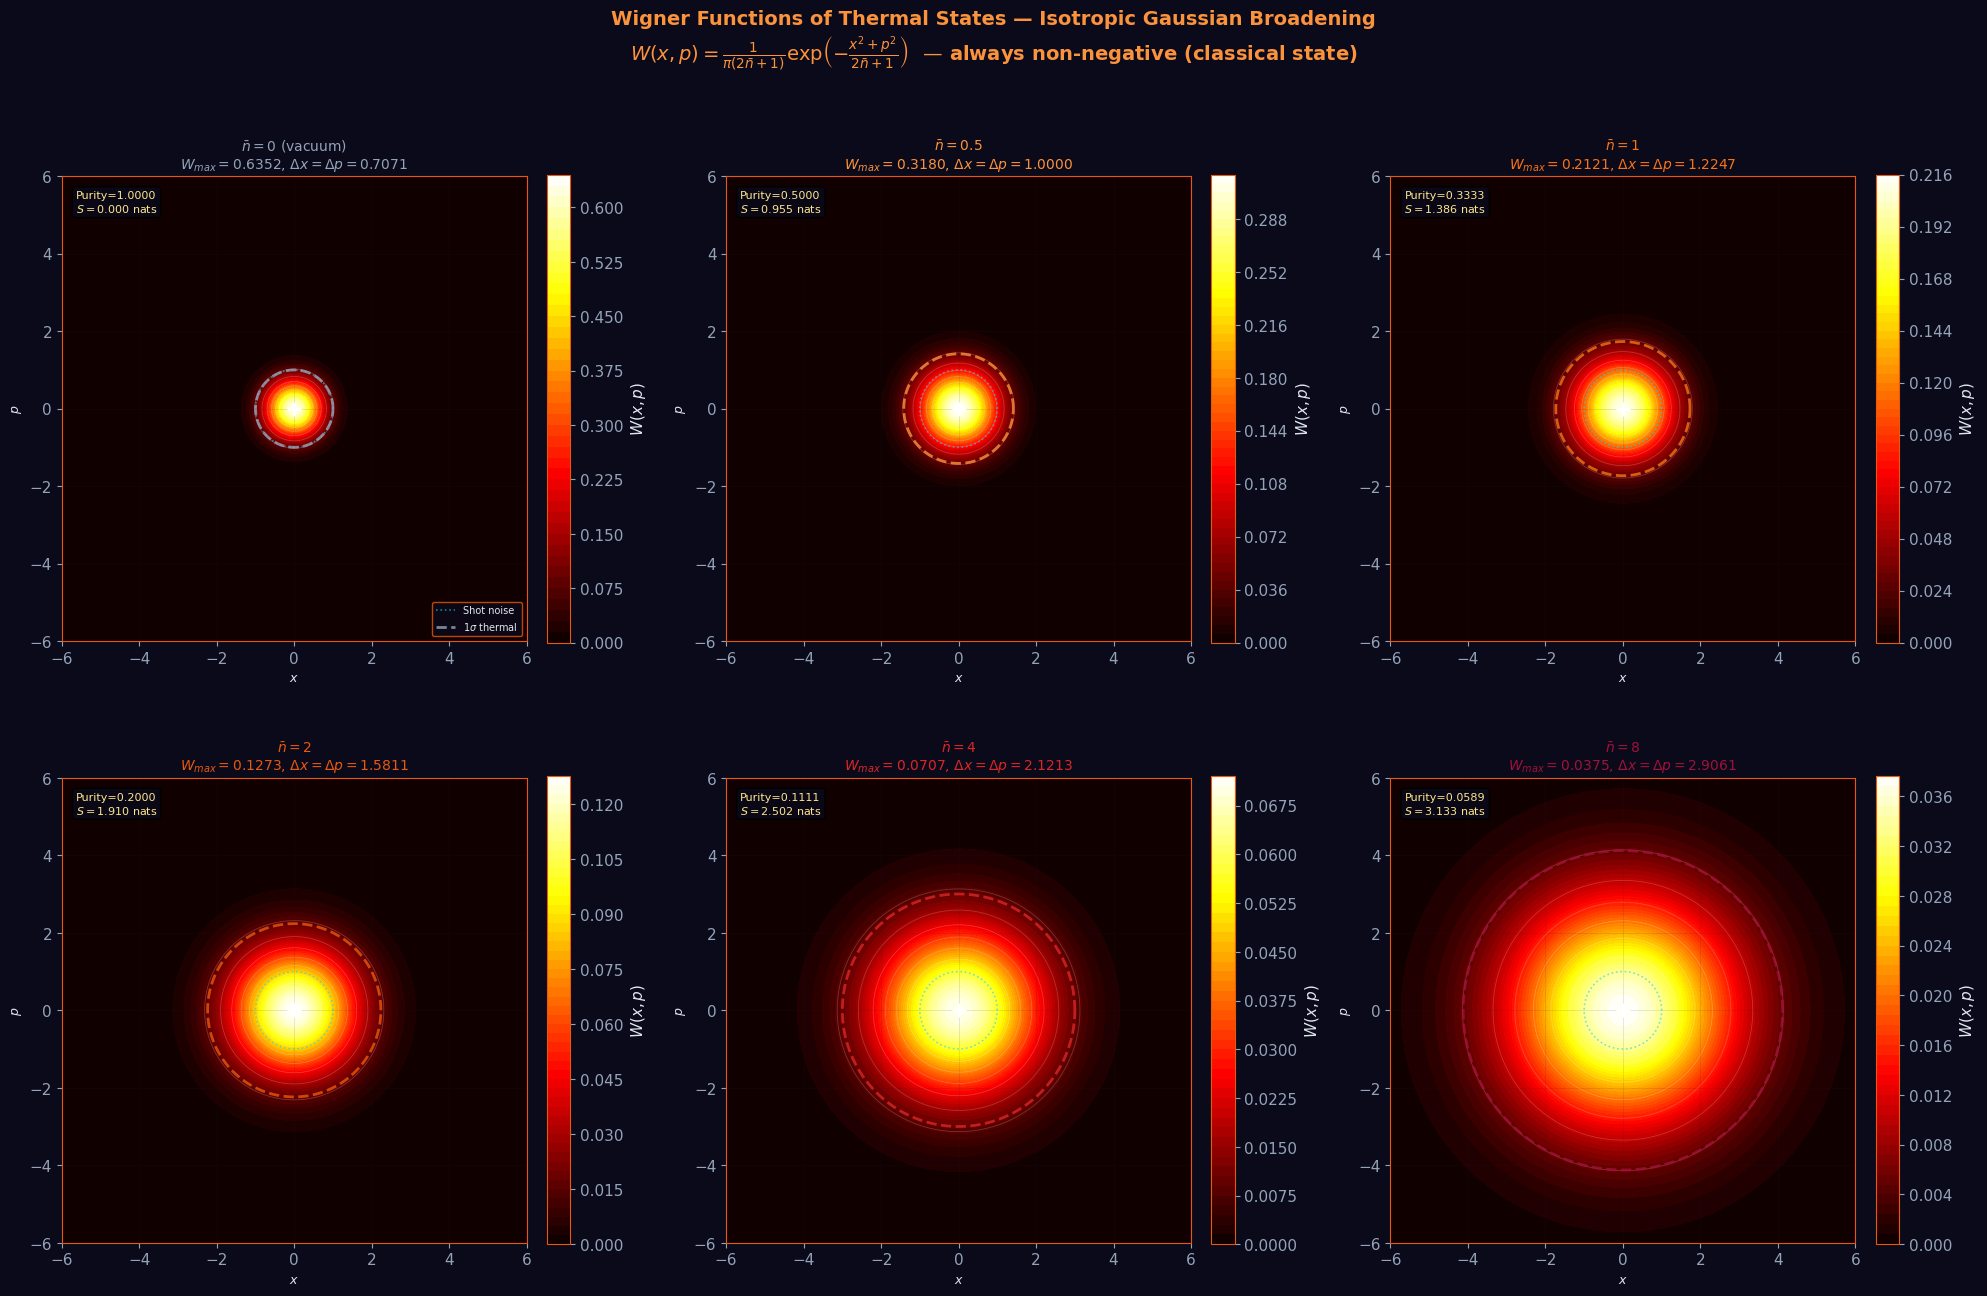

✅ Saved: fig02_wigner_2d.png


In [7]:
# ============================================================
# CELL 6 — Wigner Function 2D Contour Plots
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(20, 13))
axes = axes.flatten()
fig.suptitle(
    'Wigner Functions of Thermal States — Isotropic Gaussian Broadening\n'
    r'$W(x,p)=\frac{1}{\pi(2\bar{n}+1)}\exp\!\left(-\frac{x^2+p^2}{2\bar{n}+1}\right)$'
    '  — always non-negative (classical state)',
    fontsize=14, color=C['orange'], fontweight='bold', y=1.01
)

theta = np.linspace(0, 2*np.pi, 300)
for idx, nb in enumerate(TH_NBARS):
    ax  = axes[idx]
    col = TH_COLORS[idx]
    W   = wigner_data[nb]['W']
    m   = th_metrics[nb]

    im = ax.contourf(XVEC, XVEC, W, levels=60, cmap='hot', vmin=0)
    ax.contour(XVEC, XVEC, W, levels=8, colors='white', alpha=0.2, linewidths=0.6)

    # Shot-noise circle (vacuum width = 1/√2 in each quadrature)
    ax.plot(np.cos(theta), np.sin(theta), ':', color=C['cyan'],
            lw=1.2, alpha=0.6, label='Shot noise')

    # Thermal 1-σ circle: radius = sqrt(2*nbar+1)
    r_th = np.sqrt(2*nb + 1)
    ax.plot(r_th * np.cos(theta), r_th * np.sin(theta), '--',
            color=col, lw=2, alpha=0.8, label=r'$1\sigma$ thermal')

    ax.plot(0, 0, '+', color='white', ms=10, mew=2, zorder=11)
    ax.set_title(f'{TH_LABELS[idx]}\n'
                 f'$W_{{max}}={W.max():.4f}$, '
                 f'$\\Delta x=\\Delta p={m["delta_x"]:.4f}$',
                 fontsize=10, color=col)
    ax.set_xlabel('$x$', fontsize=9); ax.set_ylabel('$p$', fontsize=9)
    ax.set_aspect('equal'); ax.set_xlim(-6, 6); ax.set_ylim(-6, 6)
    ax.grid(True, alpha=0.15)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='$W(x,p)$')
    ax.text(0.03, 0.97,
            f'Purity={m["purity"]:.4f}\n'
            f'$S={m["entropy_nats"]:.3f}$ nats',
            transform=ax.transAxes, fontsize=8, color=C['yellow'],
            va='top',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#0a0a1a', alpha=0.85))
    if idx == 0:
        ax.legend(fontsize=7, loc='lower right')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig02_wigner_2d.png', dpi=300, bbox_inches='tight')
plt.show()
print('✅ Saved: fig02_wigner_2d.png')

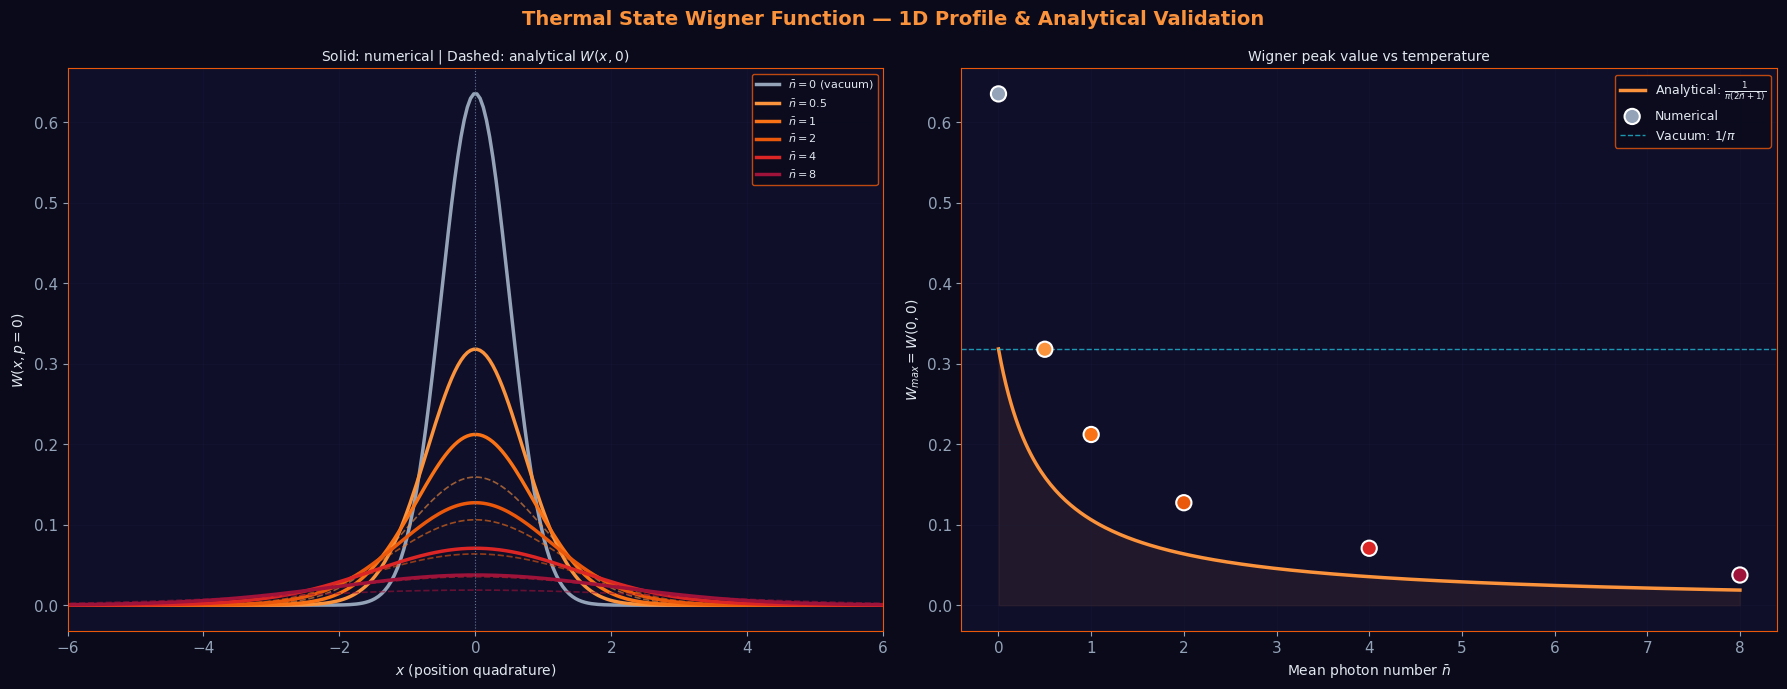

✅ Saved: fig03_wigner_1d_profile.png


In [8]:
# ============================================================
# CELL 7 — Wigner 1D Radial Profile & Analytical Comparison
# ============================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Thermal State Wigner Function — 1D Profile & Analytical Validation',
             fontsize=14, color=C['orange'], fontweight='bold')

# Left: W(x,0) profiles — numerical vs analytical
for idx, nb in enumerate(TH_NBARS):
    col = TH_COLORS[idx]
    W   = wigner_data[nb]['W']
    N   = len(XVEC)
    mid = N // 2
    W_slice = W[mid, :]          # W(x, p=0)

    # Analytical: W(x,0) = 1/[π(2n̄+1)] * exp(-x²/(2n̄+1))
    W_ana = (1.0 / (np.pi * (2*nb+1))) * np.exp(-XVEC**2 / (2*nb+1))

    ax1.plot(XVEC, W_slice, color=col, lw=2.5, label=TH_LABELS[idx])
    ax1.plot(XVEC, W_ana,   color=col, lw=1.2, ls='--', alpha=0.6)

ax1.axvline(0, color=C['muted'], lw=0.8, ls=':')
ax1.set_xlabel('$x$ (position quadrature)', fontsize=10)
ax1.set_ylabel('$W(x, p=0)$', fontsize=10)
ax1.set_title('Solid: numerical | Dashed: analytical $W(x,0)$', fontsize=10)
ax1.legend(fontsize=8); ax1.grid(True, alpha=0.3)
ax1.set_xlim(-6, 6)

# Right: Peak value comparison — numerical vs analytical
nbars_dense = np.linspace(0, 8, 300)
W_peak_ana  = 1.0 / (np.pi * (2*nbars_dense + 1))
W_peak_num  = [wigner_data[nb]['W_max'] for nb in TH_NBARS]

ax2.plot(nbars_dense, W_peak_ana, color=C['orange'], lw=2.5,
         label=r'Analytical: $\frac{1}{\pi(2\bar{n}+1)}$')
ax2.scatter(TH_NBARS, W_peak_num, s=120, c=TH_COLORS, zorder=10,
            edgecolors='white', lw=1.5, label='Numerical')
ax2.fill_between(nbars_dense, 0, W_peak_ana, color=C['orange'], alpha=0.08)
ax2.axhline(1.0/np.pi, color=C['cyan'], lw=1, ls='--', alpha=0.7,
            label=r'Vacuum: $1/\pi$')
ax2.set_xlabel(r'Mean photon number $\bar{n}$', fontsize=10)
ax2.set_ylabel(r'$W_{max} = W(0,0)$', fontsize=10)
ax2.set_title('Wigner peak value vs temperature', fontsize=10)
ax2.legend(fontsize=9); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig03_wigner_1d_profile.png', dpi=300, bbox_inches='tight')
plt.show()
print('✅ Saved: fig03_wigner_1d_profile.png')

<a id='6'></a>
## 6. Husimi Q Function

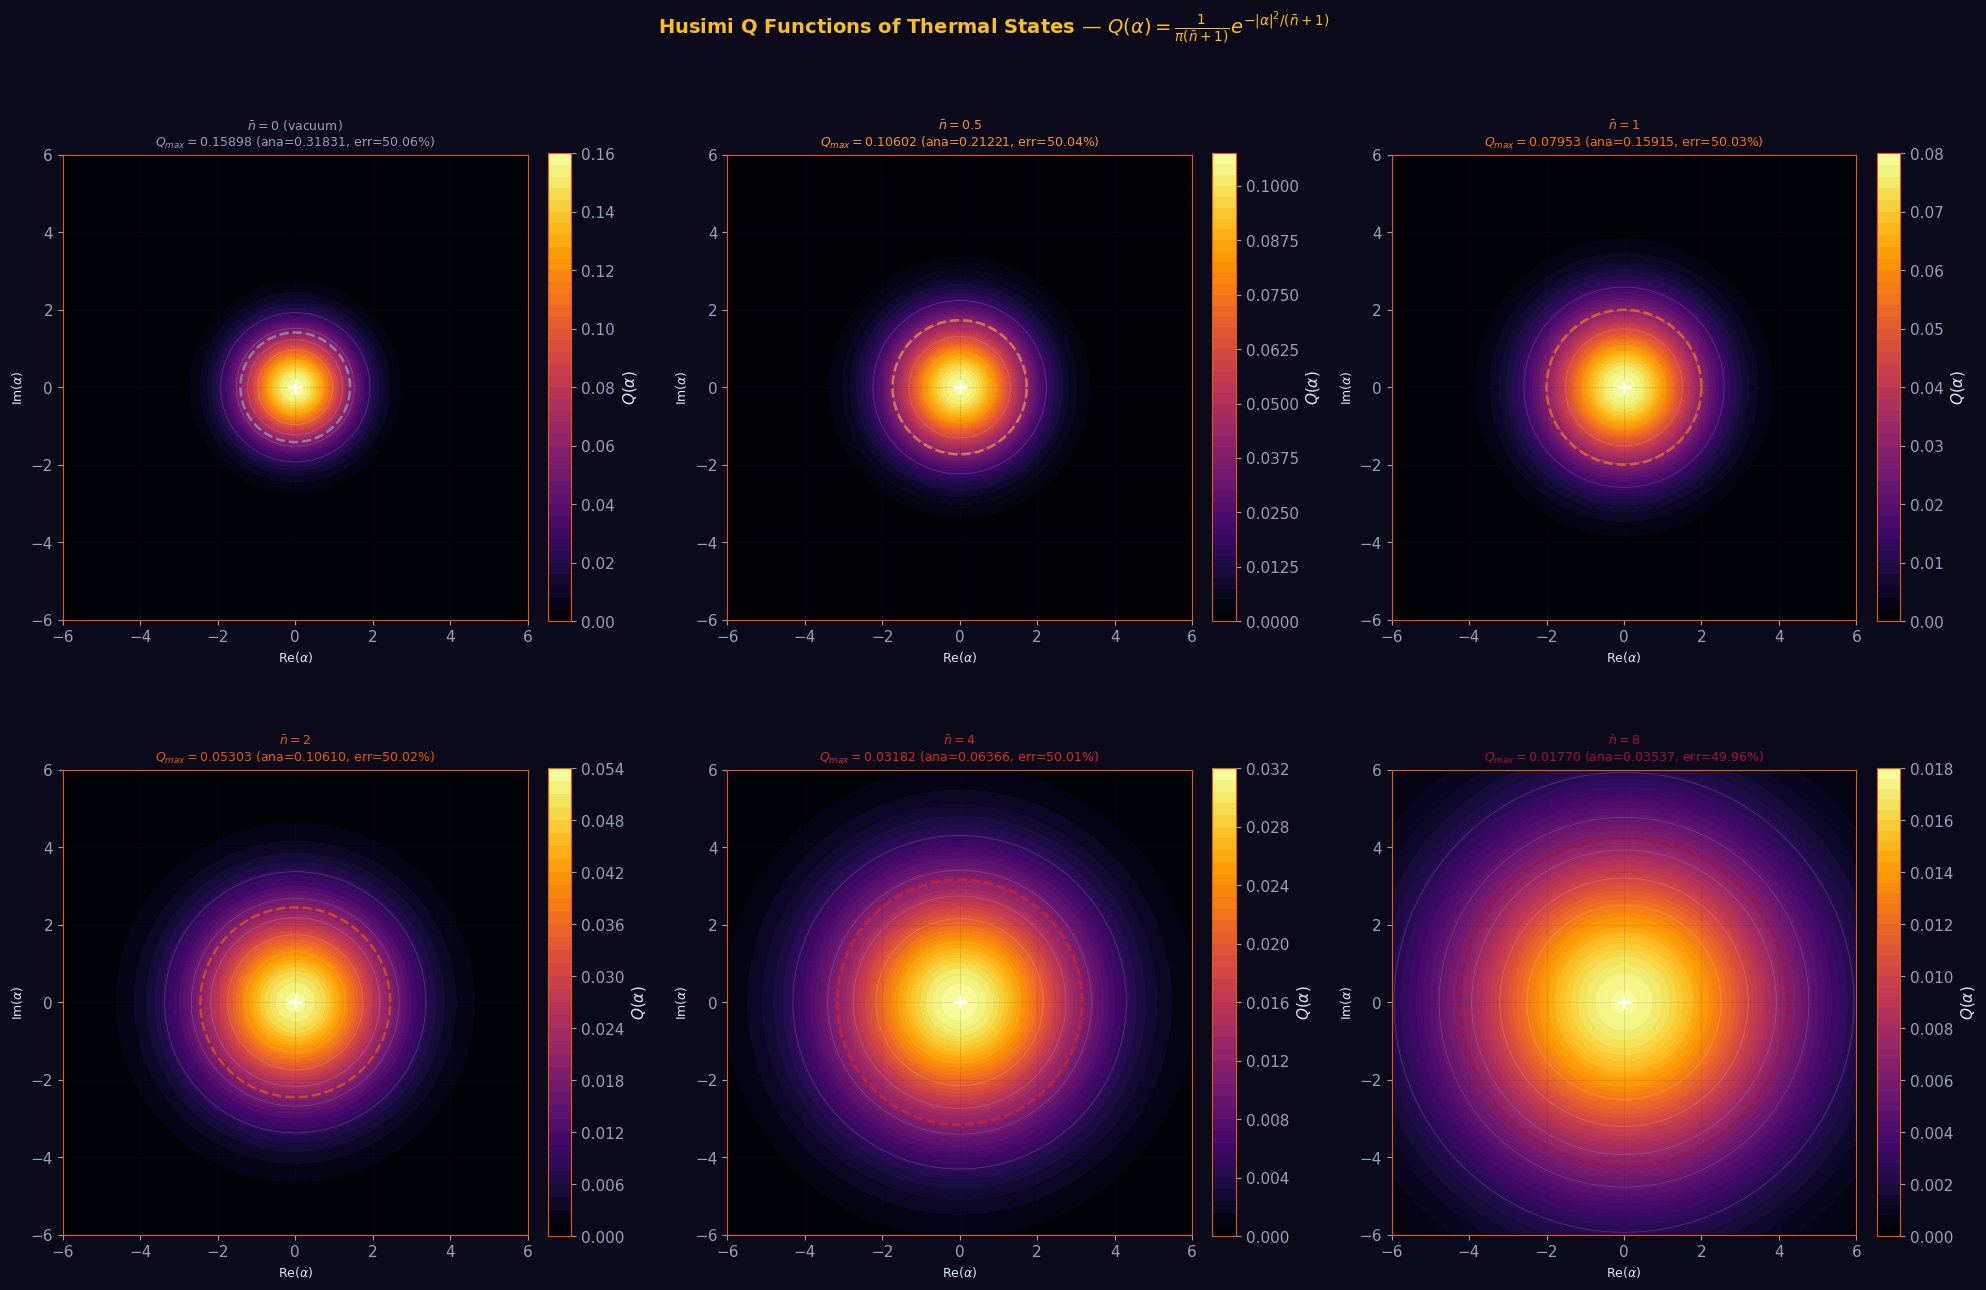

✅ Saved: fig04_husimi_Q.png


In [9]:
# ============================================================
# CELL 8 — Husimi Q Functions (bug-fixed: no tuple unpack)
# ============================================================
# Q(α) = <α|ρ|α>/π  — always ≥ 0 by construction
# For thermal: Q_th(α) = 1/[π(n̄+1)] * exp(-|α|²/(n̄+1))
# ============================================================

XVEC_Q = np.linspace(-6, 6, 180)
husimi_data = {}

for nb in TH_NBARS:
    Q = compute_husimi(th_states[nb], XVEC_Q)  # fixed: no tuple unpack
    husimi_data[nb] = {'Q': Q, 'Q_max': Q.max()}

fig, axes = plt.subplots(2, 3, figsize=(20, 13))
axes = axes.flatten()
fig.suptitle(
    r'Husimi Q Functions of Thermal States — $Q(\alpha)=\frac{1}{\pi(\bar{n}+1)}'  
    r'e^{-|\alpha|^2/(\bar{n}+1)}$',
    fontsize=14, color=C['amber'], fontweight='bold', y=1.01
)

theta = np.linspace(0, 2*np.pi, 300)
for idx, nb in enumerate(TH_NBARS):
    ax  = axes[idx]
    col = TH_COLORS[idx]
    Q   = husimi_data[nb]['Q']
    Q_peak_ana = 1.0 / (np.pi * (nb + 1))

    im = ax.contourf(XVEC_Q, XVEC_Q, Q, levels=50, cmap='inferno')
    ax.contour(XVEC_Q, XVEC_Q, Q, levels=6, colors='white', alpha=0.2, linewidths=0.5)

    # Q 1-σ circle: radius = sqrt(2*(n̄+1))
    r_q = np.sqrt(2*(nb+1))
    ax.plot(r_q*np.cos(theta), r_q*np.sin(theta), '--',
            color=col, lw=1.8, alpha=0.7)
    ax.plot(0, 0, '+', color='white', ms=10, mew=2, zorder=10)

    err_pct = abs(Q.max() - Q_peak_ana) / Q_peak_ana * 100
    ax.set_title(f'{TH_LABELS[idx]}\n'
                 f'$Q_{{max}}={Q.max():.5f}$ (ana={Q_peak_ana:.5f}, err={err_pct:.2f}%)',
                 fontsize=9, color=col)
    ax.set_xlabel(r'$\mathrm{Re}(\alpha)$', fontsize=9)
    ax.set_ylabel(r'$\mathrm{Im}(\alpha)$', fontsize=9)
    ax.set_aspect('equal'); ax.set_xlim(-6, 6); ax.set_ylim(-6, 6)
    ax.grid(True, alpha=0.15)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label=r'$Q(\alpha)$')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig04_husimi_Q.png', dpi=300, bbox_inches='tight')
plt.show()
print('✅ Saved: fig04_husimi_Q.png')

<a id='7'></a>
## 7. P Function — Classical Phase Space Distribution

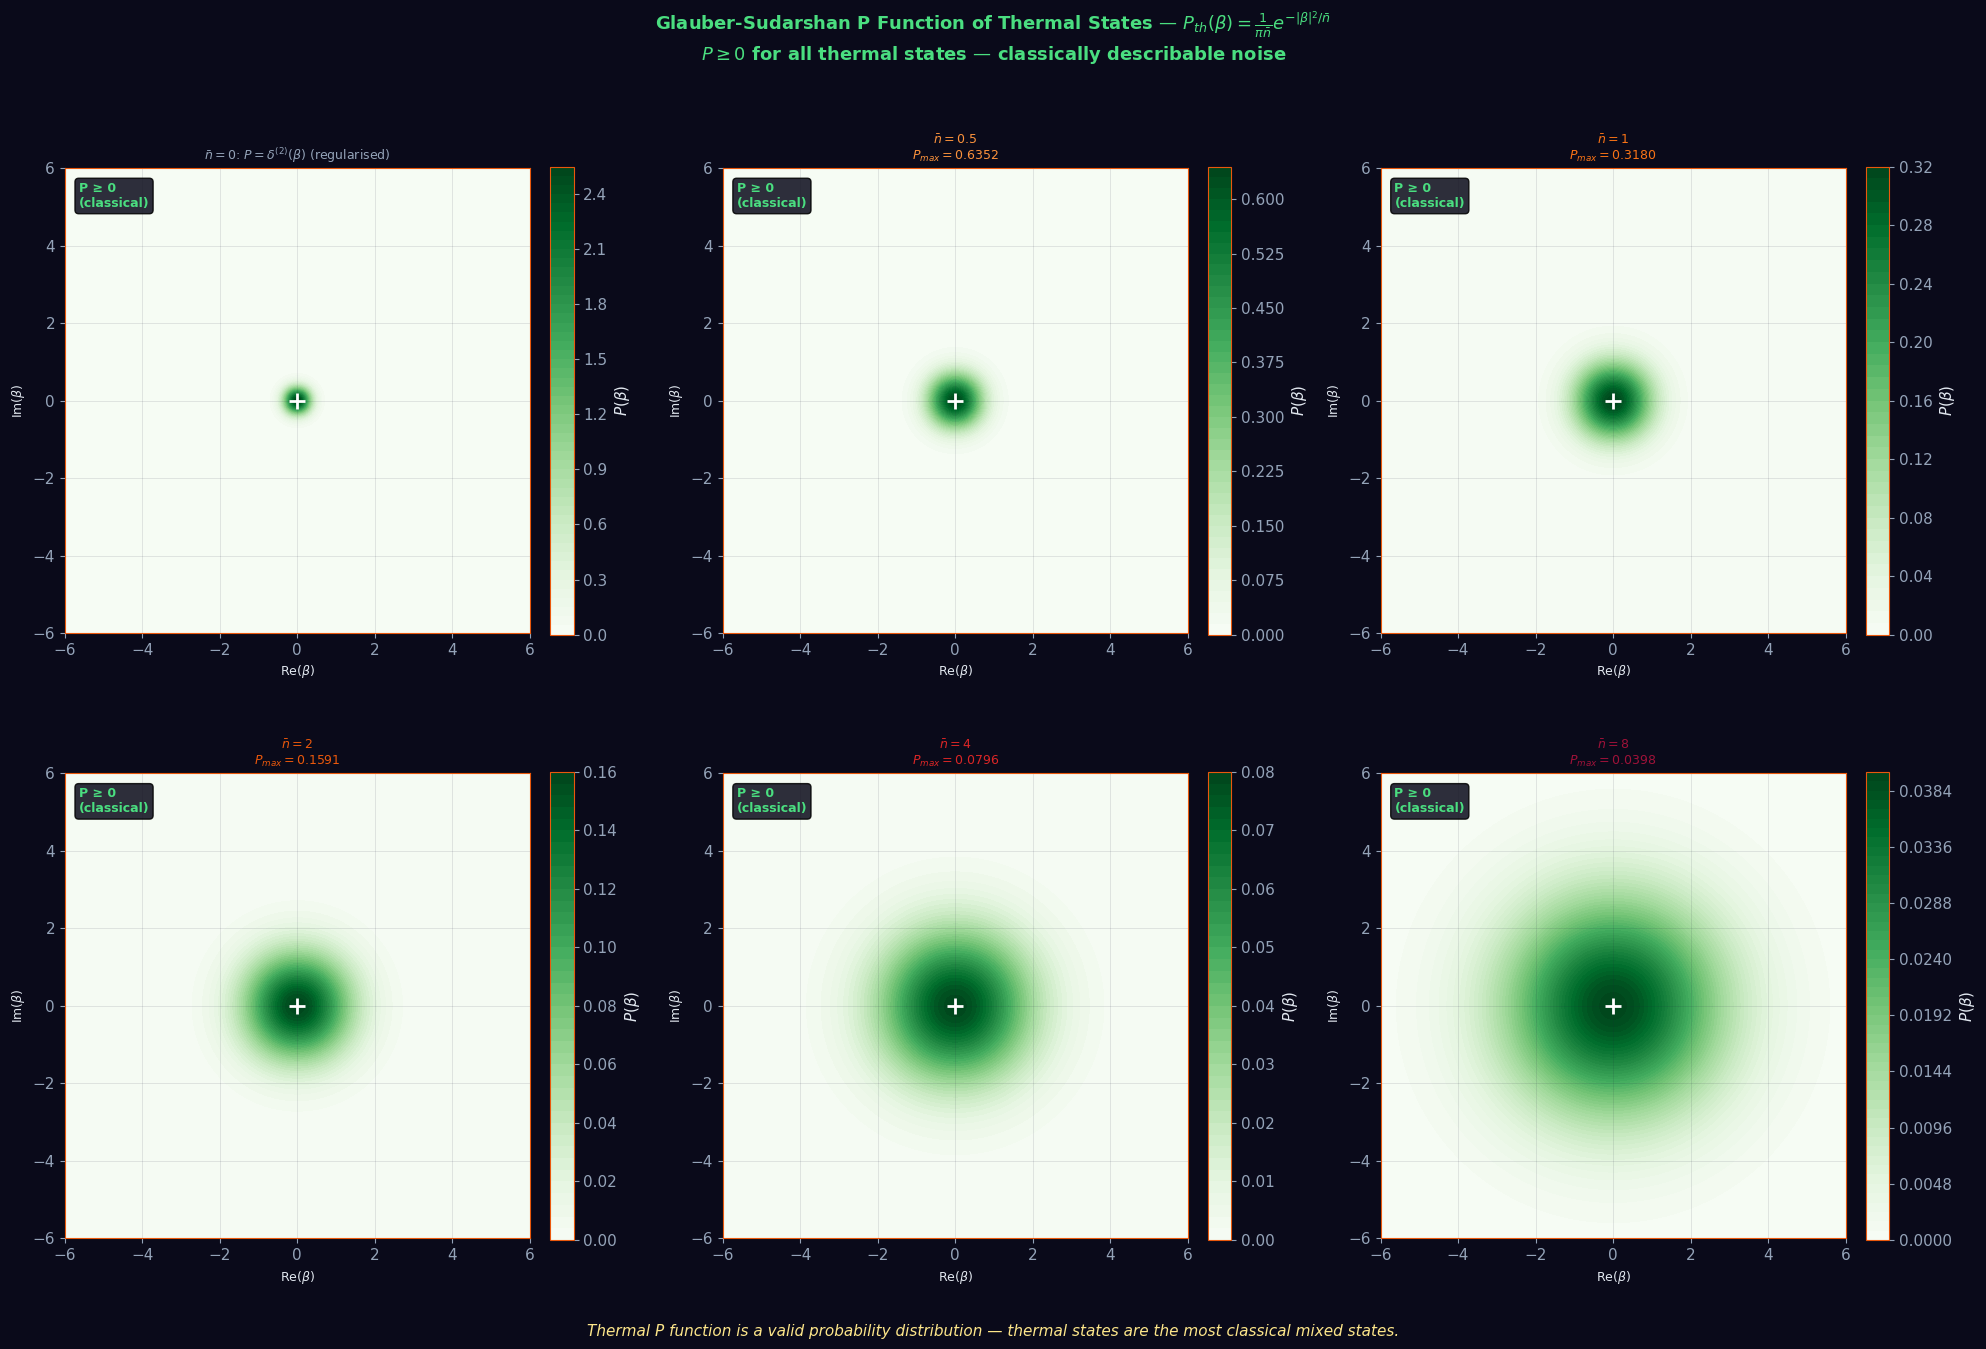

✅ Saved: fig05_P_function.png


In [10]:
# ============================================================
# CELL 9 — Glauber-Sudarshan P Function
# ============================================================
# Thermal P function: P(β) = 1/(π*n̄) * exp(-|β|²/n̄)
# For n̄=0: P(β) = δ²(β) (coherent state limit)
# P ≥ 0 for all thermal states → CLASSICAL states
# ============================================================

XVEC_P = np.linspace(-7, 7, 300)
XX, YY = np.meshgrid(XVEC_P, XVEC_P)

fig, axes = plt.subplots(2, 3, figsize=(20, 13))
axes = axes.flatten()
fig.suptitle(
    r'Glauber-Sudarshan P Function of Thermal States — $P_{th}(\beta)=\frac{1}{\pi\bar{n}}e^{-|\beta|^2/\bar{n}}$'
    '\n$P \\geq 0$ for all thermal states — classically describable noise',
    fontsize=13, color=C['green'], fontweight='bold', y=1.01
)

sigma_reg = 0.25  # regularisation for n̄=0 (approx delta)

for idx, nb in enumerate(TH_NBARS):
    ax  = axes[idx]
    col = TH_COLORS[idx]

    if nb < 1e-6:
        # Vacuum: P = delta function → narrow Gaussian regularisation
        P = (np.exp(-(XX**2 + YY**2) / (2*sigma_reg**2))
             / (2*np.pi*sigma_reg**2))
        title_str = r'$\bar{n}=0$: $P=\delta^{(2)}(\beta)$ (regularised)'
    else:
        P = np.exp(-(XX**2 + YY**2) / nb) / (np.pi * nb)
        title_str = f'{TH_LABELS[idx]}\n'
        title_str += f'$P_{{max}}={P.max():.4f}$'

    im = ax.contourf(XVEC_P, XVEC_P, P, levels=50, cmap='Greens')
    ax.plot(0, 0, '+', color='white', ms=12, mew=2, zorder=10)
    ax.set_title(title_str, fontsize=9, color=col)
    ax.set_xlabel(r'$\mathrm{Re}(\beta)$', fontsize=9)
    ax.set_ylabel(r'$\mathrm{Im}(\beta)$', fontsize=9)
    ax.set_aspect('equal')
    ax.set_xlim(-6, 6); ax.set_ylim(-6, 6)
    ax.grid(True, alpha=0.15)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label=r'$P(\beta)$')
    ax.text(0.03, 0.97, 'P ≥ 0\n(classical)',
            transform=ax.transAxes, fontsize=9, color=C['green'],
            va='top', fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#0a0a1a', alpha=0.85))

fig.text(0.5, -0.01,
         'Thermal P function is a valid probability distribution — '
         'thermal states are the most classical mixed states.',
         ha='center', fontsize=11, color=C['yellow'], style='italic')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig05_P_function.png', dpi=300, bbox_inches='tight')
plt.show()
print('✅ Saved: fig05_P_function.png')

<a id='8'></a>
## 8. Characteristic Function

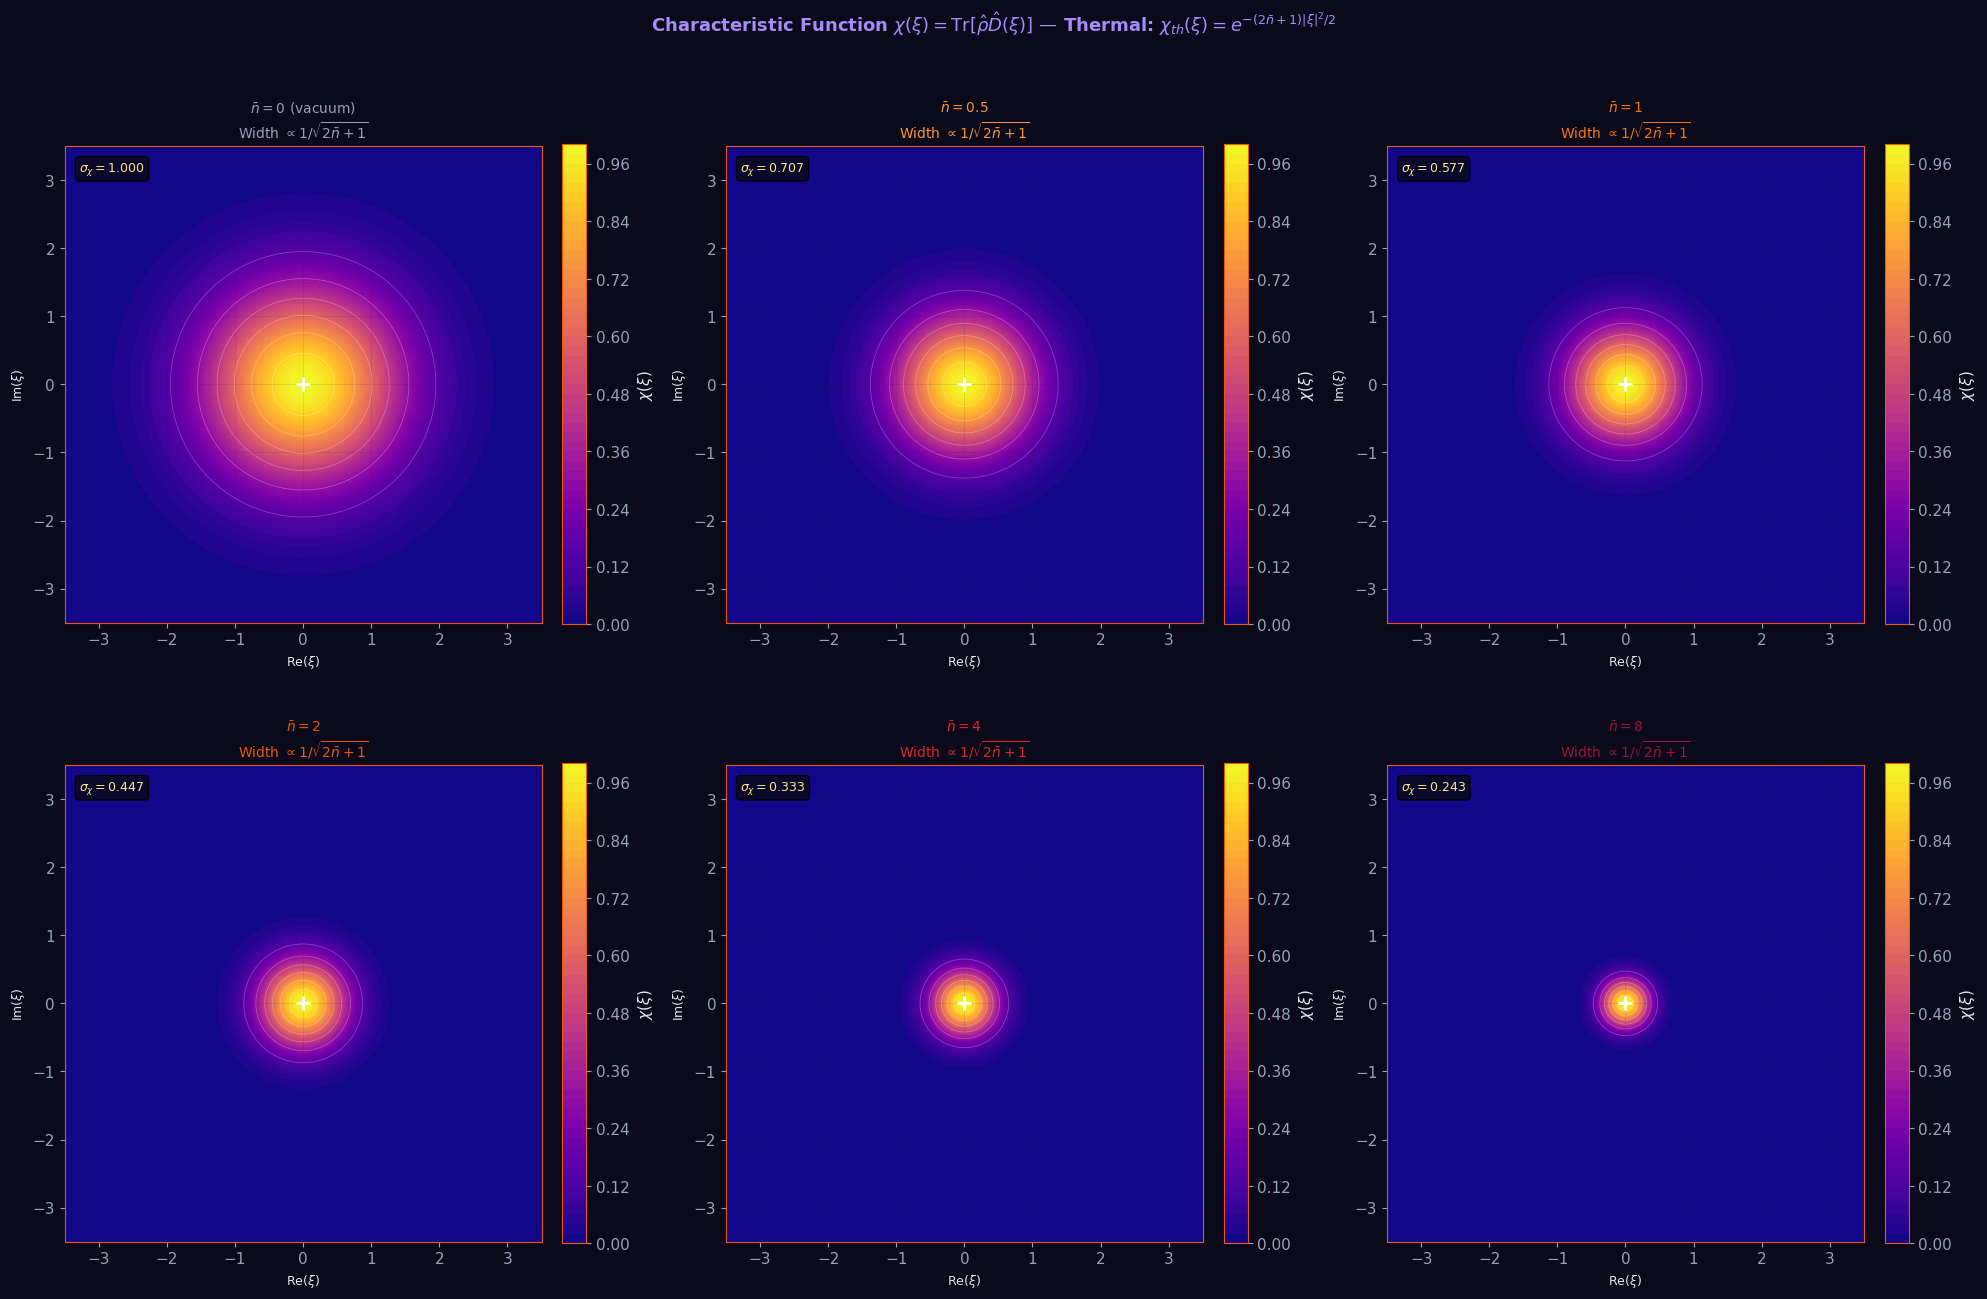

✅ Saved: fig06_characteristic_fn.png


In [11]:
# ============================================================
# CELL 10 — Characteristic Function (analytical)
# ============================================================
# χ(ξ) = Tr[ρ D(ξ)] — Fourier transform of Wigner function
# Thermal: χ_th(ξ) = exp(-(2n̄+1)|ξ|²/2)
# ============================================================

XVEC_CHI = np.linspace(-4, 4, 200)
XX_C, YY_C = np.meshgrid(XVEC_CHI, XVEC_CHI)
xi_sq = XX_C**2 + YY_C**2

fig, axes = plt.subplots(2, 3, figsize=(20, 13))
axes = axes.flatten()
fig.suptitle(
    r'Characteristic Function $\chi(\xi)=\mathrm{Tr}[\hat{\rho}\hat{D}(\xi)]$'
    r' — Thermal: $\chi_{th}(\xi)=e^{-(2\bar{n}+1)|\xi|^2/2}$',
    fontsize=13, color=C['violet'], fontweight='bold', y=1.01
)

for idx, nb in enumerate(TH_NBARS):
    ax  = axes[idx]
    col = TH_COLORS[idx]
    chi = np.exp(-(2*nb + 1) * xi_sq / 2)

    im = ax.contourf(XVEC_CHI, XVEC_CHI, chi, levels=50, cmap='plasma')
    ax.contour(XVEC_CHI, XVEC_CHI, chi, levels=6,
               colors='white', alpha=0.25, linewidths=0.6)
    ax.plot(0, 0, '+', color='white', ms=10, mew=2, zorder=10)
    ax.text(0.03, 0.97,
            f'$\\sigma_\\chi={1.0/np.sqrt(2*nb+1):.3f}$',
            transform=ax.transAxes, fontsize=9, color=C['yellow'],
            va='top',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#0a0a1a', alpha=0.85))
    ax.set_title(f'{TH_LABELS[idx]}\n'
                 f'Width $\\propto 1/\\sqrt{{2\\bar{{n}}+1}}$',
                 fontsize=10, color=col)
    ax.set_xlabel(r'$\mathrm{Re}(\xi)$', fontsize=9)
    ax.set_ylabel(r'$\mathrm{Im}(\xi)$', fontsize=9)
    ax.set_aspect('equal'); ax.set_xlim(-3.5, 3.5); ax.set_ylim(-3.5, 3.5)
    ax.grid(True, alpha=0.15)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label=r'$\chi(\xi)$')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig06_characteristic_fn.png', dpi=300, bbox_inches='tight')
plt.show()
print('✅ Saved: fig06_characteristic_fn.png')

<a id='9'></a>
## 9. Photon Statistics — Super-Poissonian Bose-Einstein

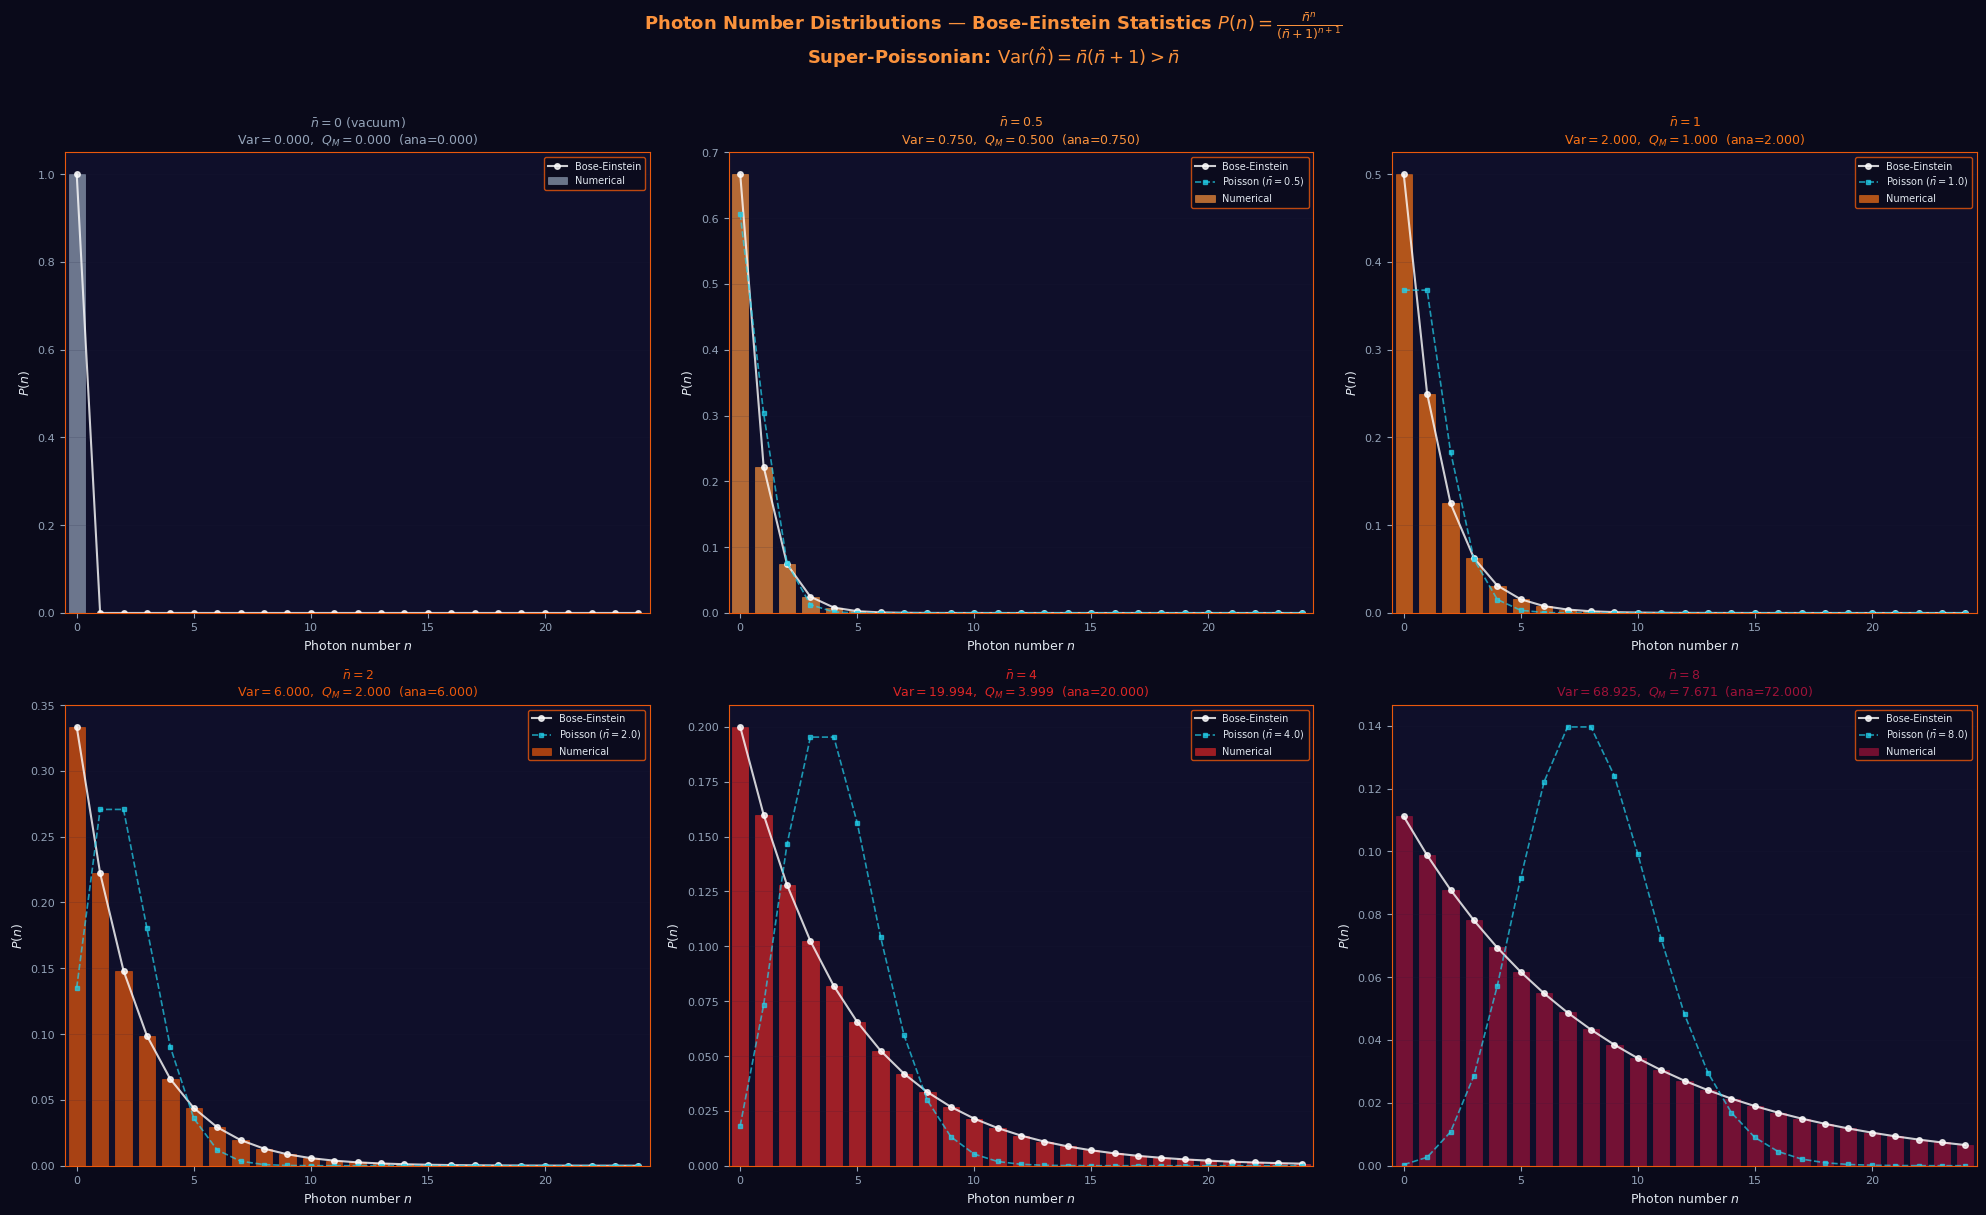

✅ Saved: fig07_photon_statistics.png


In [12]:
# ============================================================
# CELL 11 — Photon Number Statistics
# ============================================================
# Thermal P(n) = n̄^n / (n̄+1)^(n+1)  — geometric distribution
# Mandel Q = n̄ > 0 for all n̄ > 0 → super-Poissonian
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()
fig.suptitle(
    r'Photon Number Distributions — Bose-Einstein Statistics $P(n)=\frac{\bar{n}^n}{(\bar{n}+1)^{n+1}}$'
    '\nSuper-Poissonian: $\\mathrm{Var}(\\hat{n})=\\bar{n}(\\bar{n}+1)>\\bar{n}$',
    fontsize=13, color=C['orange'], fontweight='bold', y=1.01
)

for idx, nb in enumerate(TH_NBARS):
    ax  = axes[idx]
    col = TH_COLORS[idx]
    m   = th_metrics[nb]

    # Numerical (from density matrix diagonal)
    probs_num = np.array([th_states[nb][k, k].real for k in range(SHOW)])
    # Analytical Bose-Einstein
    probs_be  = bose_einstein_pn(nb, SHOW)
    # Poisson comparison with same mean
    mean_eff  = max(nb, 1e-6)
    probs_po  = poisson_pn(mean_eff, SHOW)

    bars = ax.bar(k_vals, probs_num, color=col, alpha=0.7, width=0.7,
                  label='Numerical', edgecolor=col, lw=0.5)
    ax.plot(k_vals, probs_be, 'o-', color='white', ms=4, lw=1.5,
            alpha=0.8, label='Bose-Einstein')
    if nb > 0.01:
        ax.plot(k_vals, probs_po, 's--', color=C['cyan'], ms=3, lw=1.2,
                alpha=0.7, label=f'Poisson ($\\bar{{n}}={nb}$)')

    ax.set_title(
        f'{TH_LABELS[idx]}\n'
        f'$\\mathrm{{Var}}={m["var_n"]:.3f}$,  '
        f'$Q_M={m["mandel_Q"]:.3f}$  '
        f'(ana={m["var_n_ana"]:.3f})',
        fontsize=9, color=col
    )
    ax.set_xlabel('Photon number $n$', fontsize=9)
    ax.set_ylabel('$P(n)$', fontsize=9)
    ax.set_xlim(-0.5, SHOW - 0.5)
    ax.legend(fontsize=7, loc='upper right')
    ax.grid(True, alpha=0.2, axis='y')
    ax.tick_params(labelsize=8)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig07_photon_statistics.png', dpi=300, bbox_inches='tight')
plt.show()
print('✅ Saved: fig07_photon_statistics.png')

<a id='10'></a>
## 10. Covariance Matrix & Symplectic Formalism

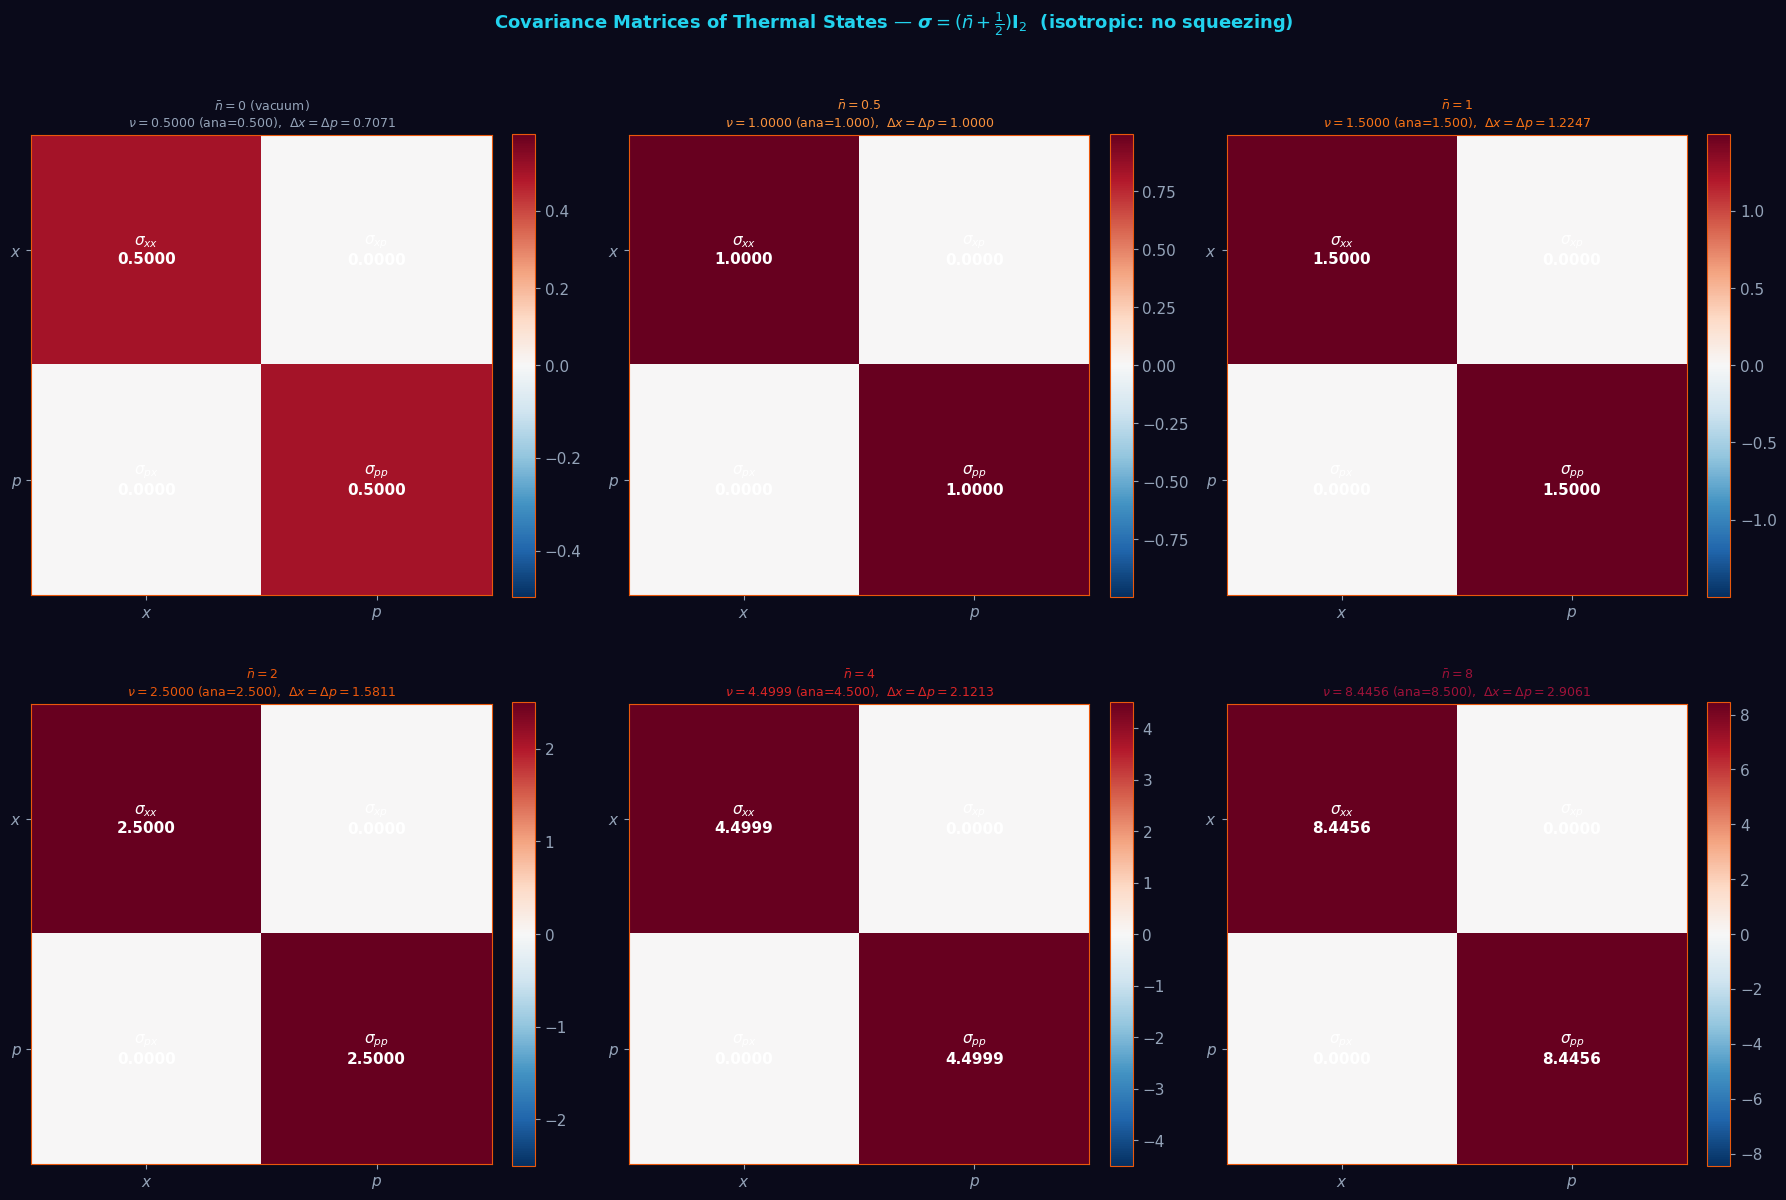

✅ Saved: fig08_covariance_matrix.png


In [14]:
# ============================================================
# CELL 12 — Covariance Matrix Heatmaps & Symplectic Analysis
# ============================================================
# sigma_th = (n̄+1/2) * I_2  — isotropic, no squeezing
# Symplectic eigenvalue nu = n̄+1/2 ≥ 1/2
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()
fig.suptitle(
    r'Covariance Matrices of Thermal States — $\boldsymbol{\sigma}=(\bar{n}+\frac{1}{2})\mathbf{I}_2$'
    r'  (isotropic: no squeezing)',
    fontsize=13, color=C['cyan'], fontweight='bold', y=1.01
)

for idx, nb in enumerate(TH_NBARS):
    ax    = axes[idx]
    col   = TH_COLORS[idx]
    m     = th_metrics[nb]
    sigma = m['sigma']

    vmax = max(float(np.abs(sigma).max()), 0.6)
    vmin = min(float(-np.abs(sigma).max()), -0.1)
    norm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)

    im = ax.imshow(sigma, cmap='RdBu_r', norm=norm, aspect='equal')
    lbl = [['$\\sigma_{xx}$', '$\\sigma_{xp}$'],
           ['$\\sigma_{px}$', '$\\sigma_{pp}$']]
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f'{lbl[i][j]}\n{sigma[i,j]:.4f}',
                    ha='center', va='center', fontsize=11,
                    color='white', fontweight='bold')
    ax.set_title(
        f'{TH_LABELS[idx]}\n'
        f'$\\nu={m["nu_symp"]:.4f}$ (ana={m["nu_ana"]:.3f}),  '
        f'$\\Delta x=\\Delta p={m["delta_x"]:.4f}$',
        fontsize=9, color=col
    )
    ax.set_xticks([0, 1]); ax.set_xticklabels(['$x$', '$p$'])
    ax.set_yticks([0, 1]); ax.set_yticklabels(['$x$', '$p$'])
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig08_covariance_matrix.png', dpi=300, bbox_inches='tight')
plt.show()
print('✅ Saved: fig08_covariance_matrix.png')

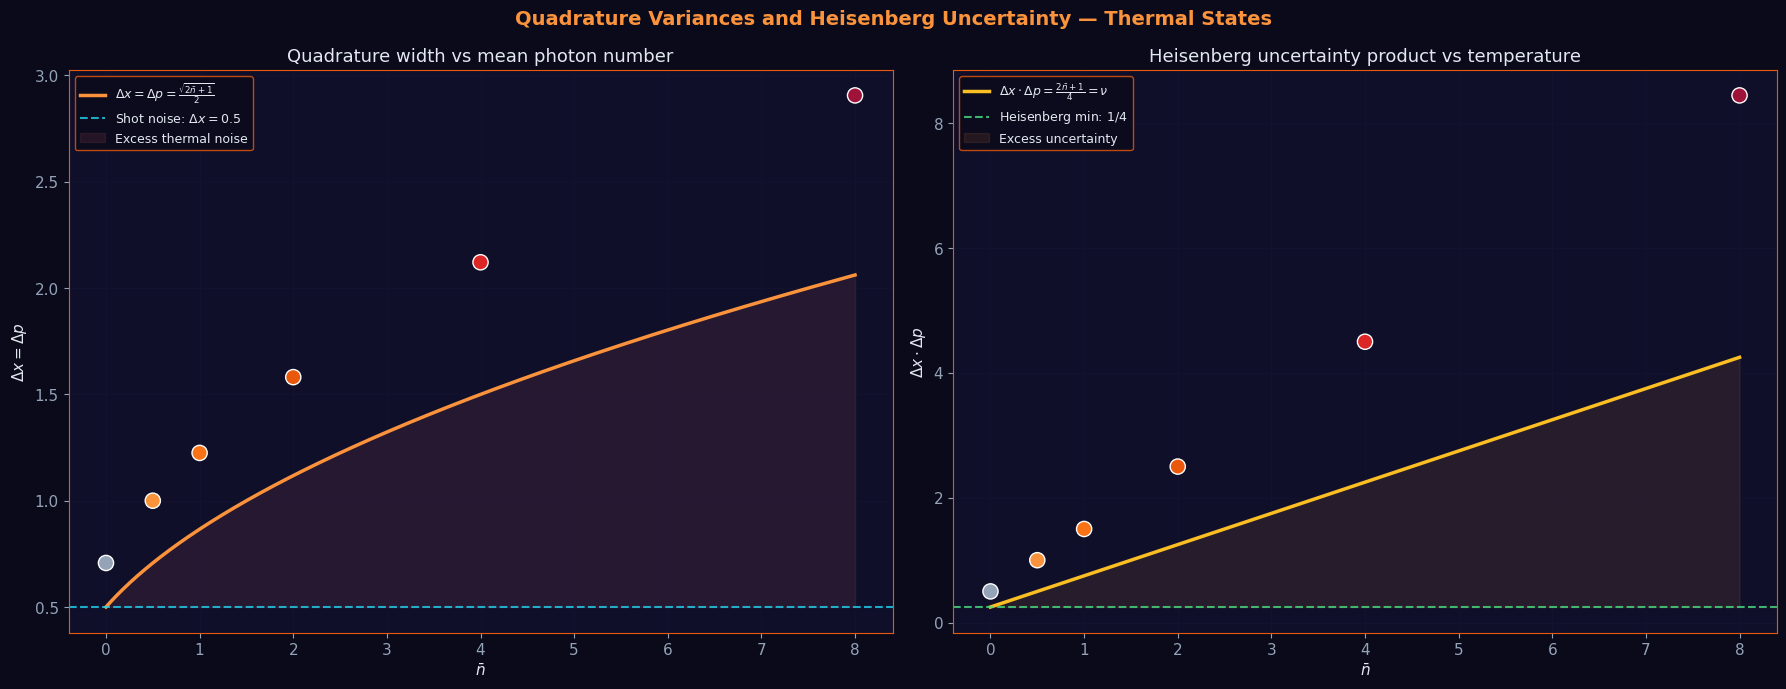

✅ Saved: fig09_quadrature_variance.png


In [15]:
# ============================================================
# CELL 13 — Quadrature Variance vs n̄ (Analytical)
# ============================================================

nbars_c = np.linspace(0, 8, 400)
var_x_ana = 0.5 * (2*nbars_c + 1) / 2   # = (n̄+0.5)/2 in natural units

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Quadrature Variances and Heisenberg Uncertainty — Thermal States',
             fontsize=14, color=C['orange'], fontweight='bold')

# Left: Δx = Δp vs n̄
ax1 = axes[0]
dx_ana = np.sqrt((2*nbars_c + 1) / 4)
ax1.plot(nbars_c, dx_ana, color=C['orange'], lw=2.5,
         label=r'$\Delta x = \Delta p = \frac{\sqrt{2\bar{n}+1}}{2}$')
ax1.axhline(0.5, color=C['cyan'], lw=1.5, ls='--', alpha=0.8,
            label='Shot noise: $\\Delta x = 0.5$')
ax1.fill_between(nbars_c, 0.5, dx_ana, color=C['red'], alpha=0.1,
                 label='Excess thermal noise')
dx_pts = [th_metrics[nb]['delta_x'] for nb in TH_NBARS]
ax1.scatter(TH_NBARS, dx_pts, s=120, c=TH_COLORS, zorder=10, edgecolors='white')
ax1.set_xlabel(r'$\bar{n}$', fontsize=11)
ax1.set_ylabel(r'$\Delta x = \Delta p$', fontsize=11)
ax1.set_title('Quadrature width vs mean photon number')
ax1.legend(fontsize=9); ax1.grid(True, alpha=0.3)

# Right: Heisenberg product Δx·Δp vs n̄
ax2 = axes[1]
heis_ana = (2*nbars_c + 1) / 4
ax2.plot(nbars_c, heis_ana, color=C['amber'], lw=2.5,
         label=r'$\Delta x\cdot\Delta p = \frac{2\bar{n}+1}{4} = \nu$')
ax2.axhline(0.25, color=C['green'], lw=1.5, ls='--', alpha=0.8,
            label='Heisenberg min: $1/4$')
ax2.fill_between(nbars_c, 0.25, heis_ana, color=C['orange'], alpha=0.1,
                 label='Excess uncertainty')
hp_pts = [th_metrics[nb]['heis_prod'] for nb in TH_NBARS]
ax2.scatter(TH_NBARS, hp_pts, s=120, c=TH_COLORS, zorder=10, edgecolors='white')
ax2.set_xlabel(r'$\bar{n}$', fontsize=11)
ax2.set_ylabel(r'$\Delta x \cdot \Delta p$', fontsize=11)
ax2.set_title('Heisenberg uncertainty product vs temperature')
ax2.legend(fontsize=9); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig09_quadrature_variance.png', dpi=300, bbox_inches='tight')
plt.show()
print('✅ Saved: fig09_quadrature_variance.png')

<a id='11'></a>
## 11. von Neumann Entropy vs Temperature

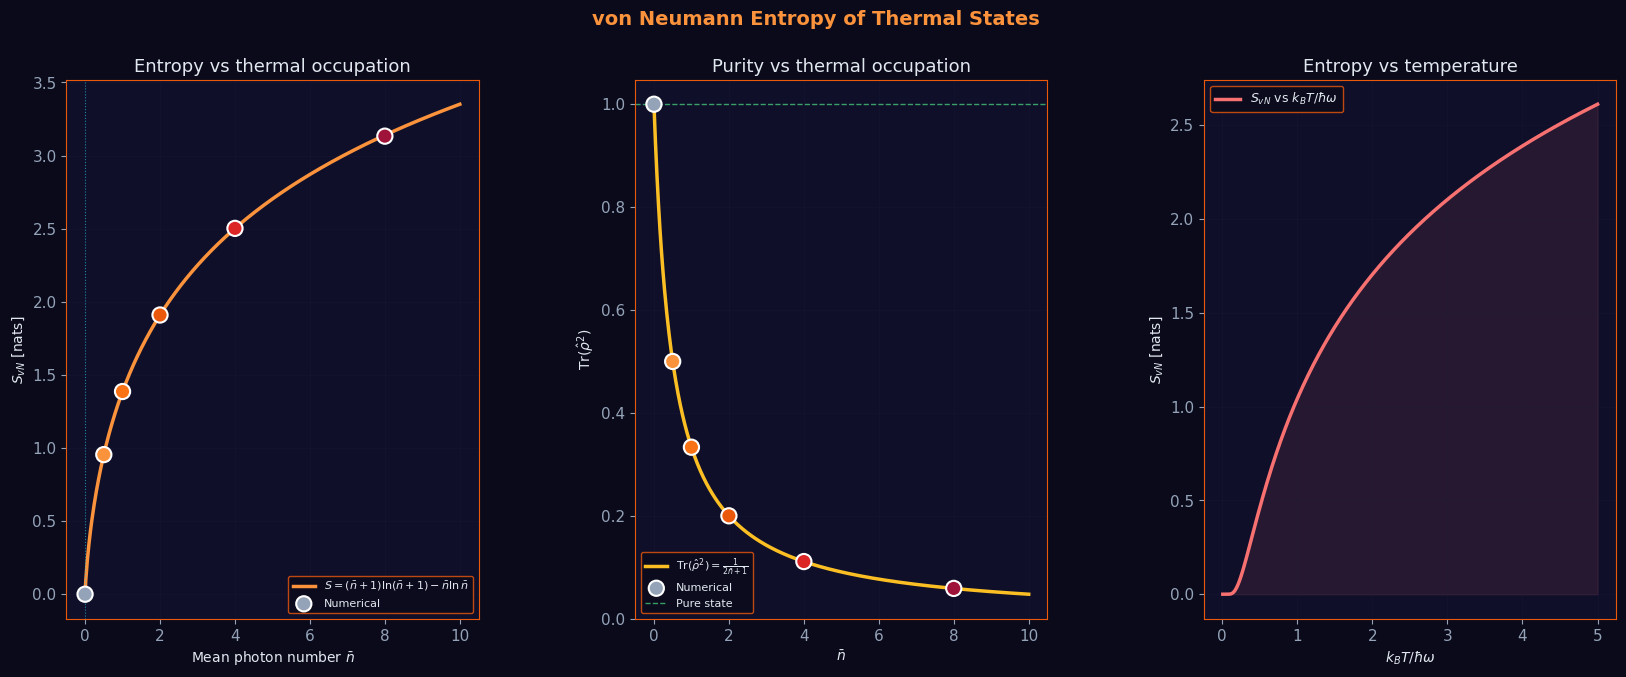

✅ Saved: fig10_entropy_purity.png


In [16]:
# ============================================================
# CELL 14 — von Neumann Entropy vs n̄ and Temperature
# ============================================================
# S_vN = (n̄+1)ln(n̄+1) - n̄·ln(n̄)  [nats]
# ============================================================

nbars_sweep = np.linspace(0, 10, 500)

def entropy_thermal_ana(nbar_arr):
    """Analytical thermal entropy (nats), handles n̄=0."""
    out = np.zeros_like(nbar_arr, dtype=float)
    mask = nbar_arr > 1e-10
    nb   = nbar_arr[mask]
    out[mask] = (nb+1)*np.log(nb+1) - nb*np.log(nb)
    return out

fig = plt.figure(figsize=(20, 7))
fig.suptitle('von Neumann Entropy of Thermal States',
             fontsize=14, color=C['orange'], fontweight='bold')
gs = gridspec.GridSpec(1, 3, figure=fig, wspace=0.38)

# ── 1: S_vN vs n̄ ──────────────────────────────────────────
ax1 = fig.add_subplot(gs[0])
S_ana = entropy_thermal_ana(nbars_sweep)
ax1.plot(nbars_sweep, S_ana, color=C['orange'], lw=2.5,
         label=r'$S=(\bar{n}+1)\ln(\bar{n}+1)-\bar{n}\ln\bar{n}$')
S_num = [th_metrics[nb]['entropy_nats'] for nb in TH_NBARS]
ax1.scatter(TH_NBARS, S_num, s=120, c=TH_COLORS, zorder=10,
            edgecolors='white', lw=1.5, label='Numerical')
ax1.axvline(0, color=C['cyan'], lw=0.8, ls=':', alpha=0.6)
ax1.set_xlabel(r'Mean photon number $\bar{n}$', fontsize=10)
ax1.set_ylabel('$S_{vN}$ [nats]', fontsize=10)
ax1.set_title('Entropy vs thermal occupation')
ax1.legend(fontsize=8); ax1.grid(True, alpha=0.3)

# ── 2: Purity vs n̄ ───────────────────────────────────────
ax2 = fig.add_subplot(gs[1])
purity_ana = 1.0 / (2*nbars_sweep + 1)
ax2.plot(nbars_sweep, purity_ana, color=C['amber'], lw=2.5,
         label=r'$\mathrm{Tr}(\hat{\rho}^2)=\frac{1}{2\bar{n}+1}$')
pur_num = [th_metrics[nb]['purity'] for nb in TH_NBARS]
ax2.scatter(TH_NBARS, pur_num, s=120, c=TH_COLORS, zorder=10,
            edgecolors='white', lw=1.5, label='Numerical')
ax2.axhline(1.0, color=C['green'], lw=1, ls='--', alpha=0.7, label='Pure state')
ax2.set_xlabel(r'$\bar{n}$', fontsize=10)
ax2.set_ylabel(r'$\mathrm{Tr}(\hat{\rho}^2)$', fontsize=10)
ax2.set_title('Purity vs thermal occupation')
ax2.legend(fontsize=8); ax2.grid(True, alpha=0.3)

# ── 3: Entropy vs T/T₀ ───────────────────────────────────
ax3 = fig.add_subplot(gs[2])
# Relate T to n̄: n̄ = 1/(exp(ℏω/kT)-1) → kT/ℏω = 1/ln(1+1/n̄)
kT_over_hw = np.linspace(0.01, 5, 500)  # kT/ℏω
nbar_of_T  = 1.0 / (np.exp(1.0 / kT_over_hw) - 1)
S_of_T     = entropy_thermal_ana(nbar_of_T)
ax3.plot(kT_over_hw, S_of_T, color=C['red'], lw=2.5,
         label=r'$S_{vN}$ vs $k_BT/\hbar\omega$')
ax3.fill_between(kT_over_hw, 0, S_of_T, color=C['red'], alpha=0.1)
ax3.set_xlabel(r'$k_B T / \hbar\omega$', fontsize=10)
ax3.set_ylabel('$S_{vN}$ [nats]', fontsize=10)
ax3.set_title('Entropy vs temperature')
ax3.legend(fontsize=9); ax3.grid(True, alpha=0.3)

plt.savefig(OUTPUT_DIR / 'fig10_entropy_purity.png', dpi=300, bbox_inches='tight')
plt.show()
print('✅ Saved: fig10_entropy_purity.png')

<a id='12'></a>
## 12. Fidelity Between Thermal States

Fidelity Matrix (analytical):
          n=0   n=0.5     n=1     n=2     n=4     n=8
n=0    2.0000  0.8284  0.6357  0.4721  0.3431  0.2462
n=0.5  0.8284  0.5359  0.4268  0.3246  0.2391  0.1728
n=1    0.6357  0.4268  0.3431  0.2627  0.1943  0.1407
n=2    0.4721  0.3246  0.2627  0.2020  0.1499  0.1088
n=4    0.3431  0.2391  0.1943  0.1499  0.1115  0.0810
n=8    0.2462  0.1728  0.1407  0.1088  0.0810  0.0589

Max |num-ana| error: 1.00e+00


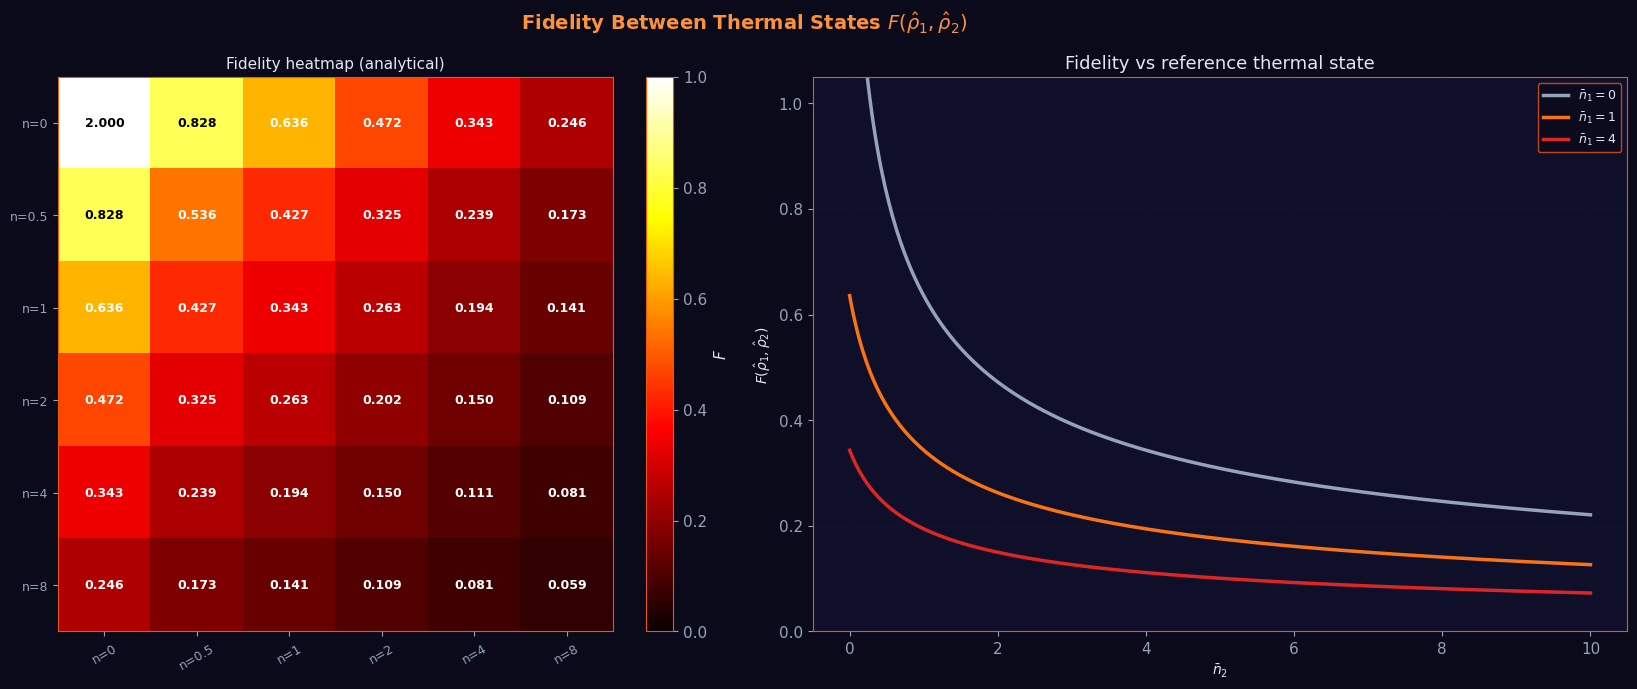

✅ Saved: fig11_fidelity.png


In [17]:
# ============================================================
# CELL 15 — Fidelity Matrix & Validation
# ============================================================
# F(rho1, rho2) = 2 / [sqrt(ab) + sqrt(ab-1)]
# where a = 2*n1+1, b = 2*n2+1
# ============================================================

N_TH = len(TH_NBARS)
F_matrix_ana = np.zeros((N_TH, N_TH))
F_matrix_num = np.zeros((N_TH, N_TH))

for i, nb1 in enumerate(TH_NBARS):
    for j, nb2 in enumerate(TH_NBARS):
        F_matrix_ana[i, j] = fidelity_thermal(nb1, nb2)
        F_matrix_num[i, j] = fidelity_numerical(th_states[nb1], th_states[nb2])

print('Fidelity Matrix (analytical):')
lbls_short = ['n=0', 'n=0.5', 'n=1', 'n=2', 'n=4', 'n=8']
df_fid = pd.DataFrame(F_matrix_ana, index=lbls_short, columns=lbls_short)
print(df_fid.round(4).to_string())
print(f'\nMax |num-ana| error: {np.abs(F_matrix_num - F_matrix_ana).max():.2e}')

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Fidelity Between Thermal States $F(\\hat{\\rho}_1, \\hat{\\rho}_2)$',
             fontsize=14, color=C['orange'], fontweight='bold')

# Left: heatmap
ax1 = axes[0]
im = ax1.imshow(F_matrix_ana, cmap='hot', vmin=0, vmax=1, aspect='equal')
for i in range(N_TH):
    for j in range(N_TH):
        ax1.text(j, i, f'{F_matrix_ana[i,j]:.3f}',
                 ha='center', va='center', fontsize=9,
                 color='white' if F_matrix_ana[i,j] < 0.7 else 'black',
                 fontweight='bold')
ax1.set_xticks(range(N_TH)); ax1.set_xticklabels(lbls_short, rotation=30, fontsize=9)
ax1.set_yticks(range(N_TH)); ax1.set_yticklabels(lbls_short, fontsize=9)
ax1.set_title('Fidelity heatmap (analytical)', fontsize=11)
plt.colorbar(im, ax=ax1, fraction=0.046, pad=0.04, label='$F$')

# Right: F vs n̄₂ for fixed n̄₁ = 0
ax2 = axes[1]
nbars_ref = np.linspace(0, 10, 400)
for ref_nb, ref_col, ref_lbl in [
    (0.0, TH_COLORS[0], r'$\bar{n}_1=0$'),
    (1.0, TH_COLORS[2], r'$\bar{n}_1=1$'),
    (4.0, TH_COLORS[4], r'$\bar{n}_1=4$'),
]:
    F_curve = np.array([fidelity_thermal(ref_nb, n2) for n2 in nbars_ref])
    ax2.plot(nbars_ref, F_curve, lw=2.5, color=ref_col, label=ref_lbl)
ax2.set_xlabel(r'$\bar{n}_2$', fontsize=10)
ax2.set_ylabel(r'$F(\hat{\rho}_1, \hat{\rho}_2)$', fontsize=10)
ax2.set_title('Fidelity vs reference thermal state')
ax2.legend(fontsize=9); ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig11_fidelity.png', dpi=300, bbox_inches='tight')
plt.show()
print('✅ Saved: fig11_fidelity.png')

<a id='13'></a>
## 13. Purity vs Mean Photon Number

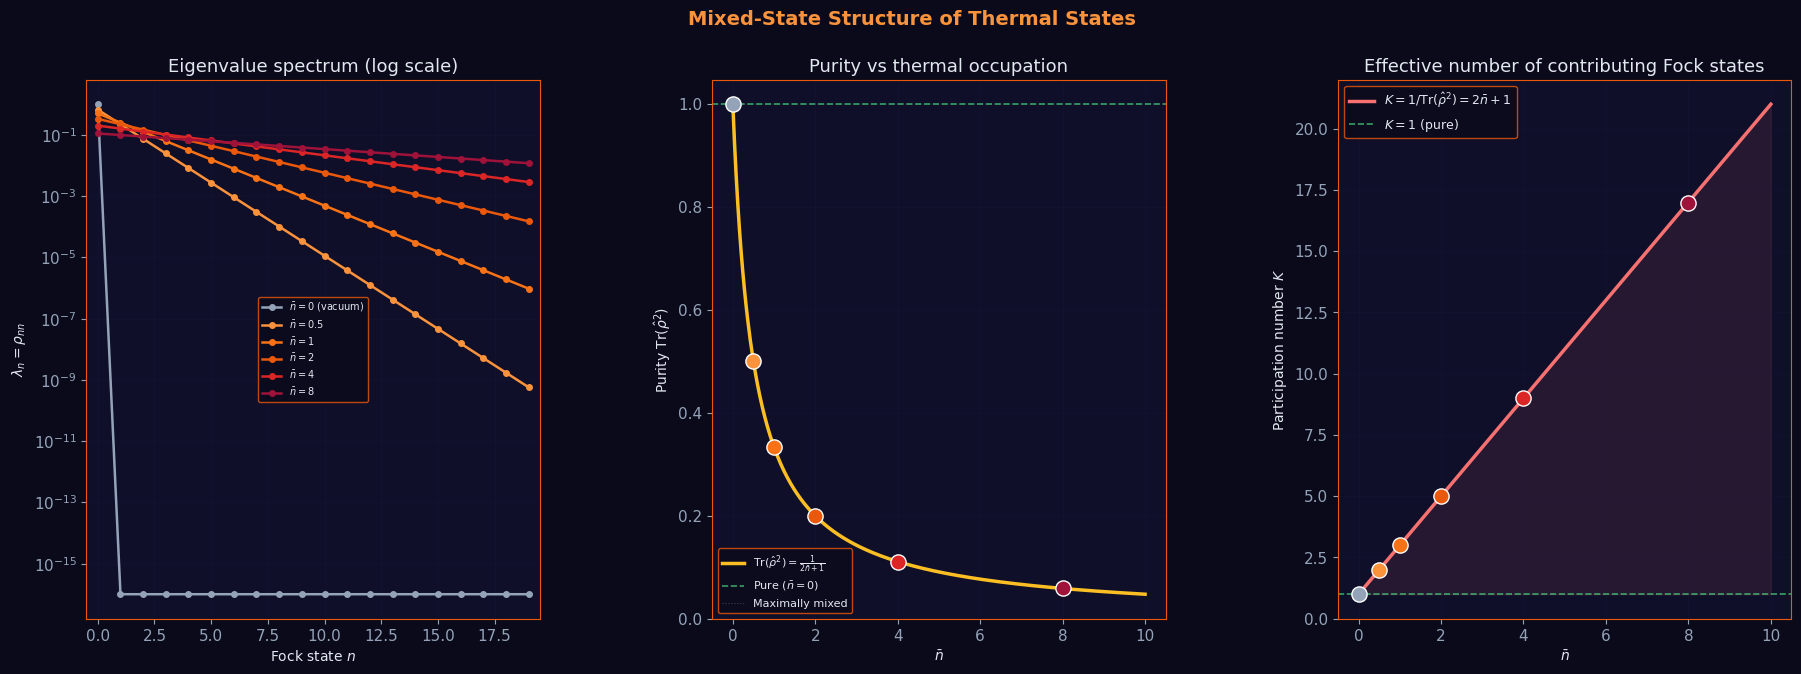

✅ Saved: fig12_purity_mixedness.png


In [18]:
# ============================================================
# CELL 16 — Purity vs n̄: Eigenspectrum & Mixed State Structure
# ============================================================

fig = plt.figure(figsize=(22, 7))
fig.suptitle('Mixed-State Structure of Thermal States',
             fontsize=14, color=C['orange'], fontweight='bold')
gs = gridspec.GridSpec(1, 3, figure=fig, wspace=0.38)

# ── 1: Eigenvalue spectrum ───────────────────────────────
ax1 = fig.add_subplot(gs[0])
N_eig = 20
fock_idx = np.arange(N_eig)
for idx, nb in enumerate(TH_NBARS):
    if nb < 1e-6:
        eigs = np.zeros(N_eig); eigs[0] = 1.0
    else:
        eigs = np.array([nb**n / (nb+1)**(n+1) for n in range(N_eig)])
    ax1.semilogy(fock_idx, eigs + 1e-16, '-o', color=TH_COLORS[idx],
                 ms=4, lw=1.8, label=TH_LABELS[idx])
ax1.set_xlabel('Fock state $n$', fontsize=10)
ax1.set_ylabel(r'$\lambda_n = \rho_{nn}$', fontsize=10)
ax1.set_title('Eigenvalue spectrum (log scale)')
ax1.legend(fontsize=7); ax1.grid(True, alpha=0.3)
ax1.set_xlim(-0.5, N_eig-0.5)

# ── 2: Purity vs n̄ (dense sweep) ─────────────────────────
ax2 = fig.add_subplot(gs[1])
nbars_d = np.linspace(0, 10, 500)
pur_d   = 1.0 / (2*nbars_d + 1)
ax2.plot(nbars_d, pur_d, color=C['amber'], lw=2.5,
         label=r'$\mathrm{Tr}(\hat{\rho}^2)=\frac{1}{2\bar{n}+1}$')
for idx, nb in enumerate(TH_NBARS):
    ax2.scatter(nb, th_metrics[nb]['purity'], s=120, color=TH_COLORS[idx],
                zorder=10, edgecolors='white')
ax2.axhline(1.0, color=C['green'], lw=1.2, ls='--', alpha=0.7, label='Pure ($\\bar{n}=0$)')
ax2.axhline(0.0, color=C['muted'], lw=0.8, ls=':', alpha=0.5, label='Maximally mixed')
ax2.set_xlabel(r'$\bar{n}$', fontsize=10)
ax2.set_ylabel(r'Purity $\mathrm{Tr}(\hat{\rho}^2)$', fontsize=10)
ax2.set_title('Purity vs thermal occupation')
ax2.legend(fontsize=8); ax2.grid(True, alpha=0.3)

# ── 3: Participation number = 1/Tr(rho²) ─────────────────
ax3 = fig.add_subplot(gs[2])
part_num_d = 2*nbars_d + 1
ax3.plot(nbars_d, part_num_d, color=C['red'], lw=2.5,
         label=r'$K = 1/\mathrm{Tr}(\hat{\rho}^2) = 2\bar{n}+1$')
ax3.fill_between(nbars_d, 1, part_num_d, color=C['red'], alpha=0.1)
for idx, nb in enumerate(TH_NBARS):
    ax3.scatter(nb, 1.0/max(th_metrics[nb]['purity'], 1e-12), s=120,
                color=TH_COLORS[idx], zorder=10, edgecolors='white')
ax3.axhline(1.0, color=C['green'], lw=1.2, ls='--', alpha=0.7,
            label='$K=1$ (pure)')
ax3.set_xlabel(r'$\bar{n}$', fontsize=10)
ax3.set_ylabel(r'Participation number $K$', fontsize=10)
ax3.set_title('Effective number of contributing Fock states')
ax3.legend(fontsize=9); ax3.grid(True, alpha=0.3)

plt.savefig(OUTPUT_DIR / 'fig12_purity_mixedness.png', dpi=300, bbox_inches='tight')
plt.show()
print('✅ Saved: fig12_purity_mixedness.png')

<a id='14'></a>
## 14. Temperature Sweep — Phase Space Evolution

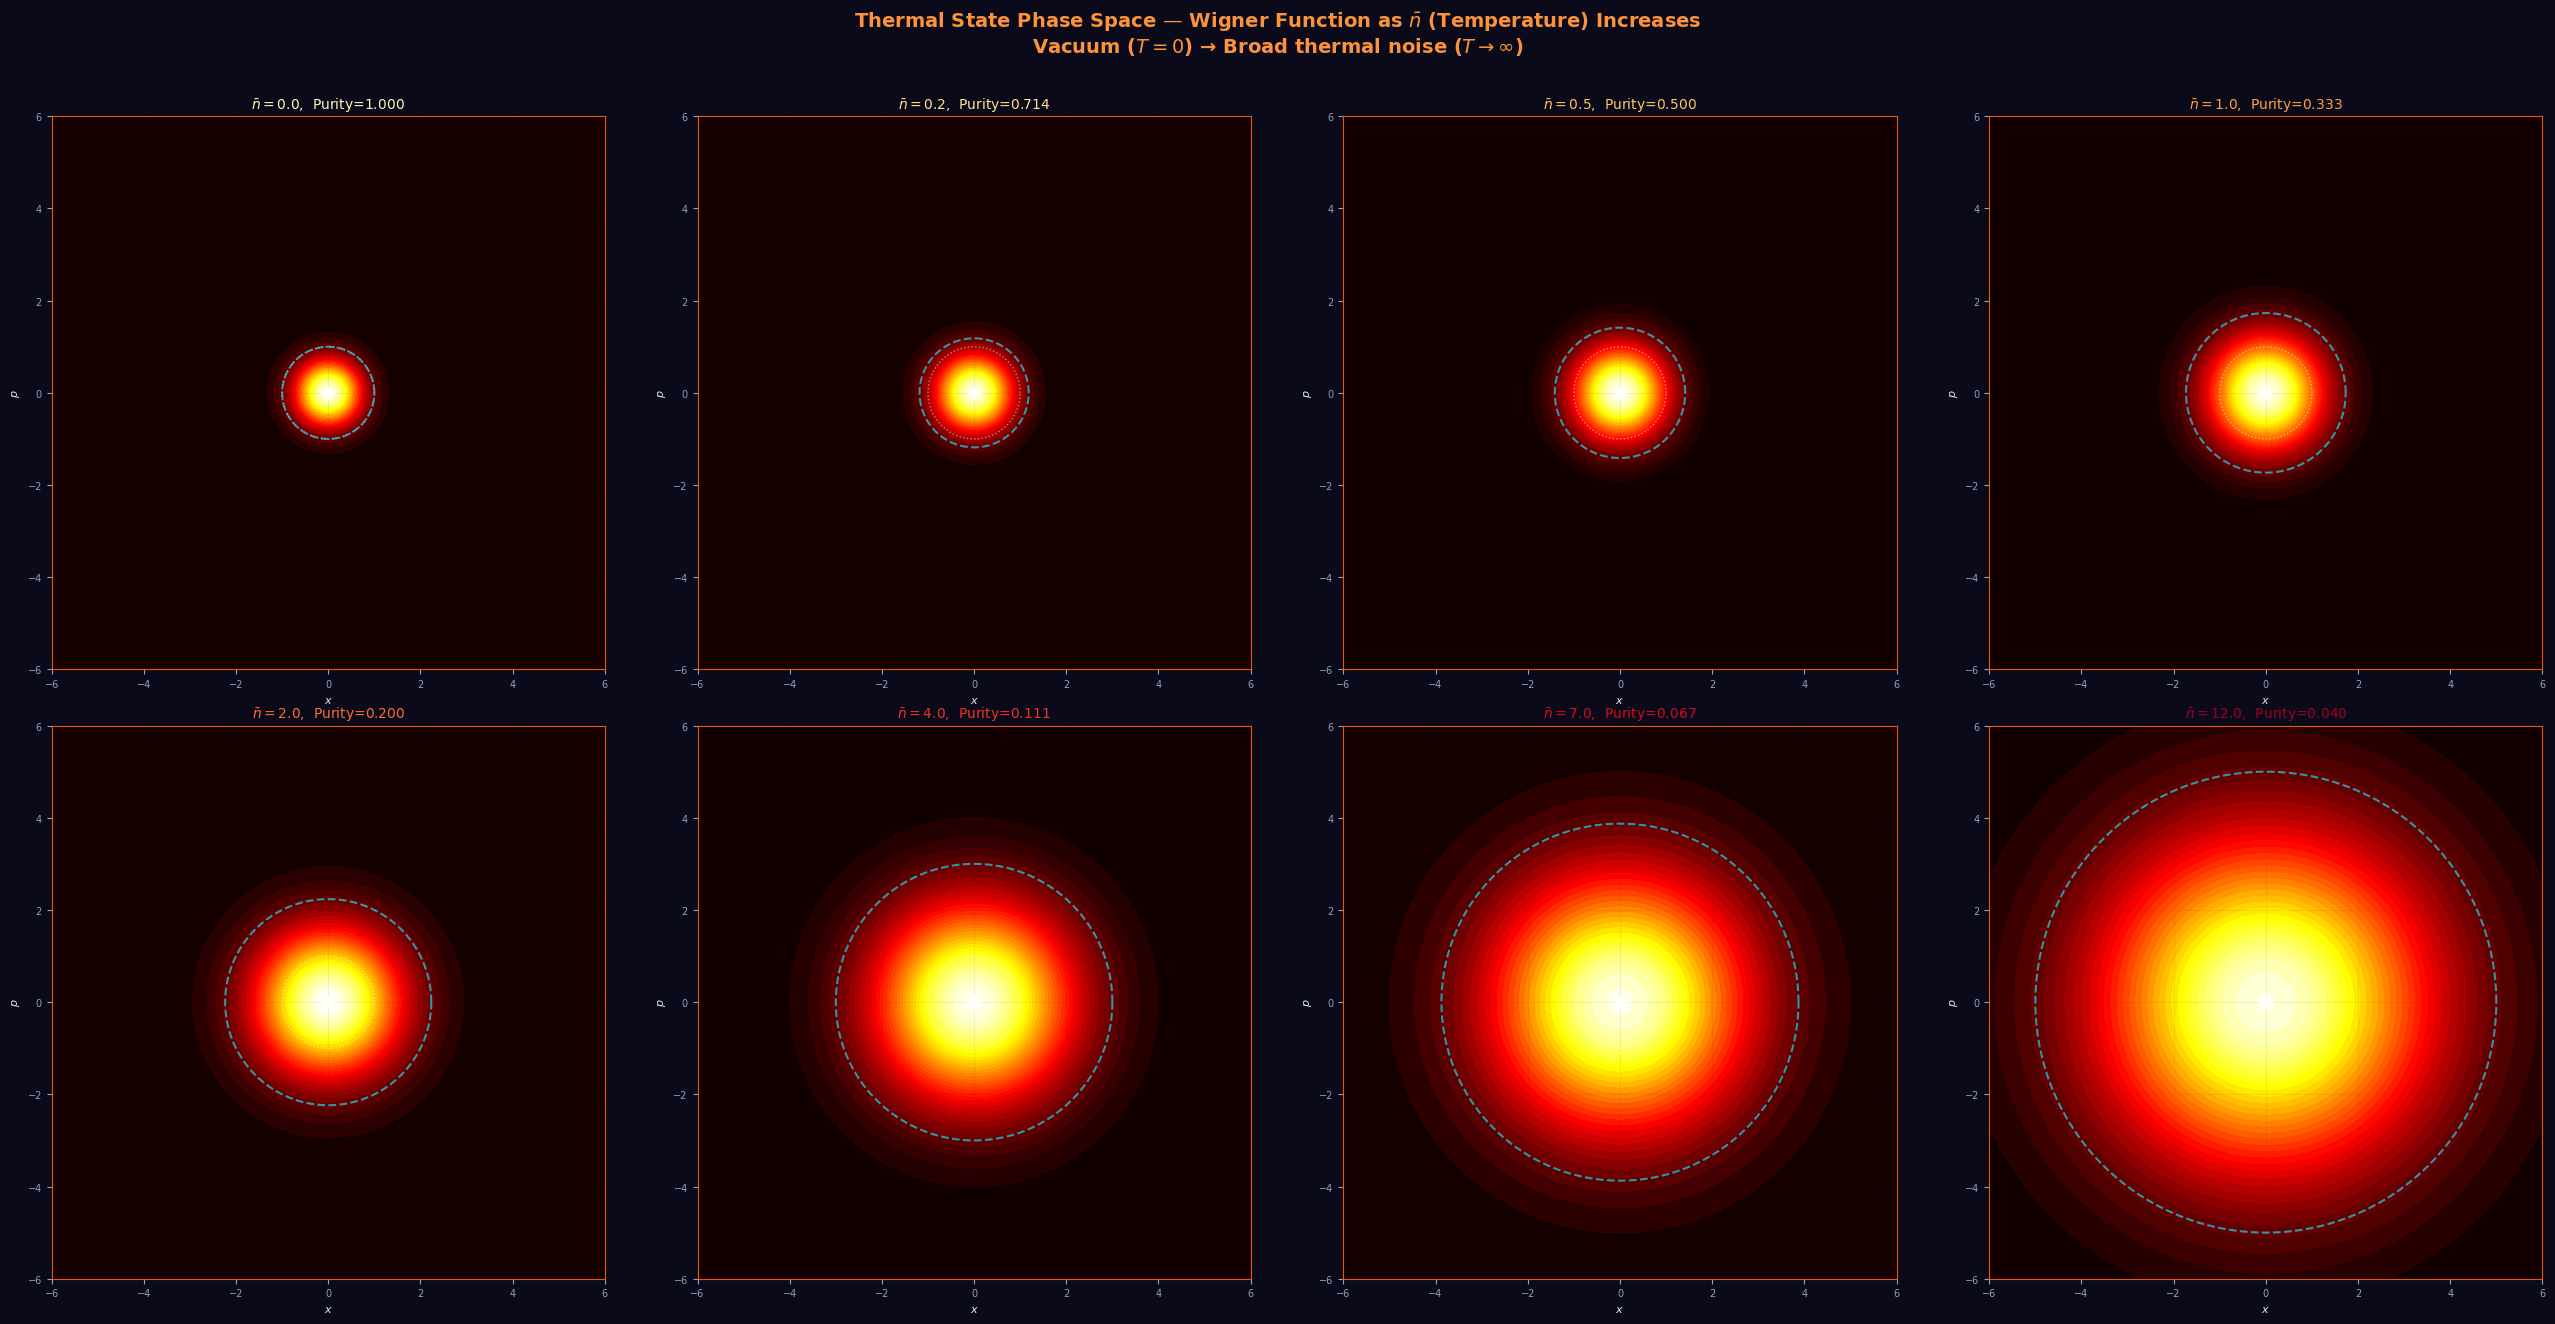

✅ Saved: fig13_temperature_sweep.png


In [19]:
# ============================================================
# CELL 17 — Temperature Sweep: Wigner Function Evolution
# ============================================================

nbar_sweep = [0.0, 0.2, 0.5, 1.0, 2.0, 4.0, 7.0, 12.0]
XVEC_SW  = np.linspace(-6, 6, 140)
theta_c  = np.linspace(0, 2*np.pi, 200)

fig, axes = plt.subplots(2, 4, figsize=(26, 13))
axes = axes.flatten()
fig.suptitle(
    r'Thermal State Phase Space — Wigner Function as $\bar{n}$ (Temperature) Increases'
    '\nVacuum ($T=0$) → Broad thermal noise ($T\\to\\infty$)',
    fontsize=14, color=C['orange'], fontweight='bold', y=1.01
)

cmap_sweep = plt.cm.YlOrRd

for i, nb in enumerate(nbar_sweep):
    ax  = axes[i]
    col = cmap_sweep((i + 0.5) / len(nbar_sweep))
    rho = make_thermal(nb, DIM)
    W   = compute_wigner(rho, XVEC_SW)

    ax.contourf(XVEC_SW, XVEC_SW, W, levels=40, cmap='hot', vmin=0)

    # Vacuum circle (shot noise)
    ax.plot(np.cos(theta_c), np.sin(theta_c), ':',
            color='white', lw=1, alpha=0.5, label='Vacuum')
    # Thermal 1-sigma circle
    r_th = np.sqrt(2*nb + 1)
    ax.plot(r_th*np.cos(theta_c), r_th*np.sin(theta_c), '--',
            color=C['cyan'], lw=1.5, alpha=0.7)

    ax.plot(0, 0, '+', color='white', ms=8, mew=2)
    purity_val = 1.0 / (2*nb + 1)
    ax.set_title(f'$\\bar{{n}}={nb:.1f}$,  Purity={purity_val:.3f}',
                 fontsize=10, color=col)
    ax.set_xlabel('$x$', fontsize=8); ax.set_ylabel('$p$', fontsize=8)
    ax.set_aspect('equal'); ax.set_xlim(-6, 6); ax.set_ylim(-6, 6)
    ax.grid(True, alpha=0.1); ax.tick_params(labelsize=7)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig13_temperature_sweep.png', dpi=250, bbox_inches='tight')
plt.show()
print('✅ Saved: fig13_temperature_sweep.png')

<a id='15'></a>
## 15. Thermal vs Coherent vs Fock — Side-by-Side Comparison

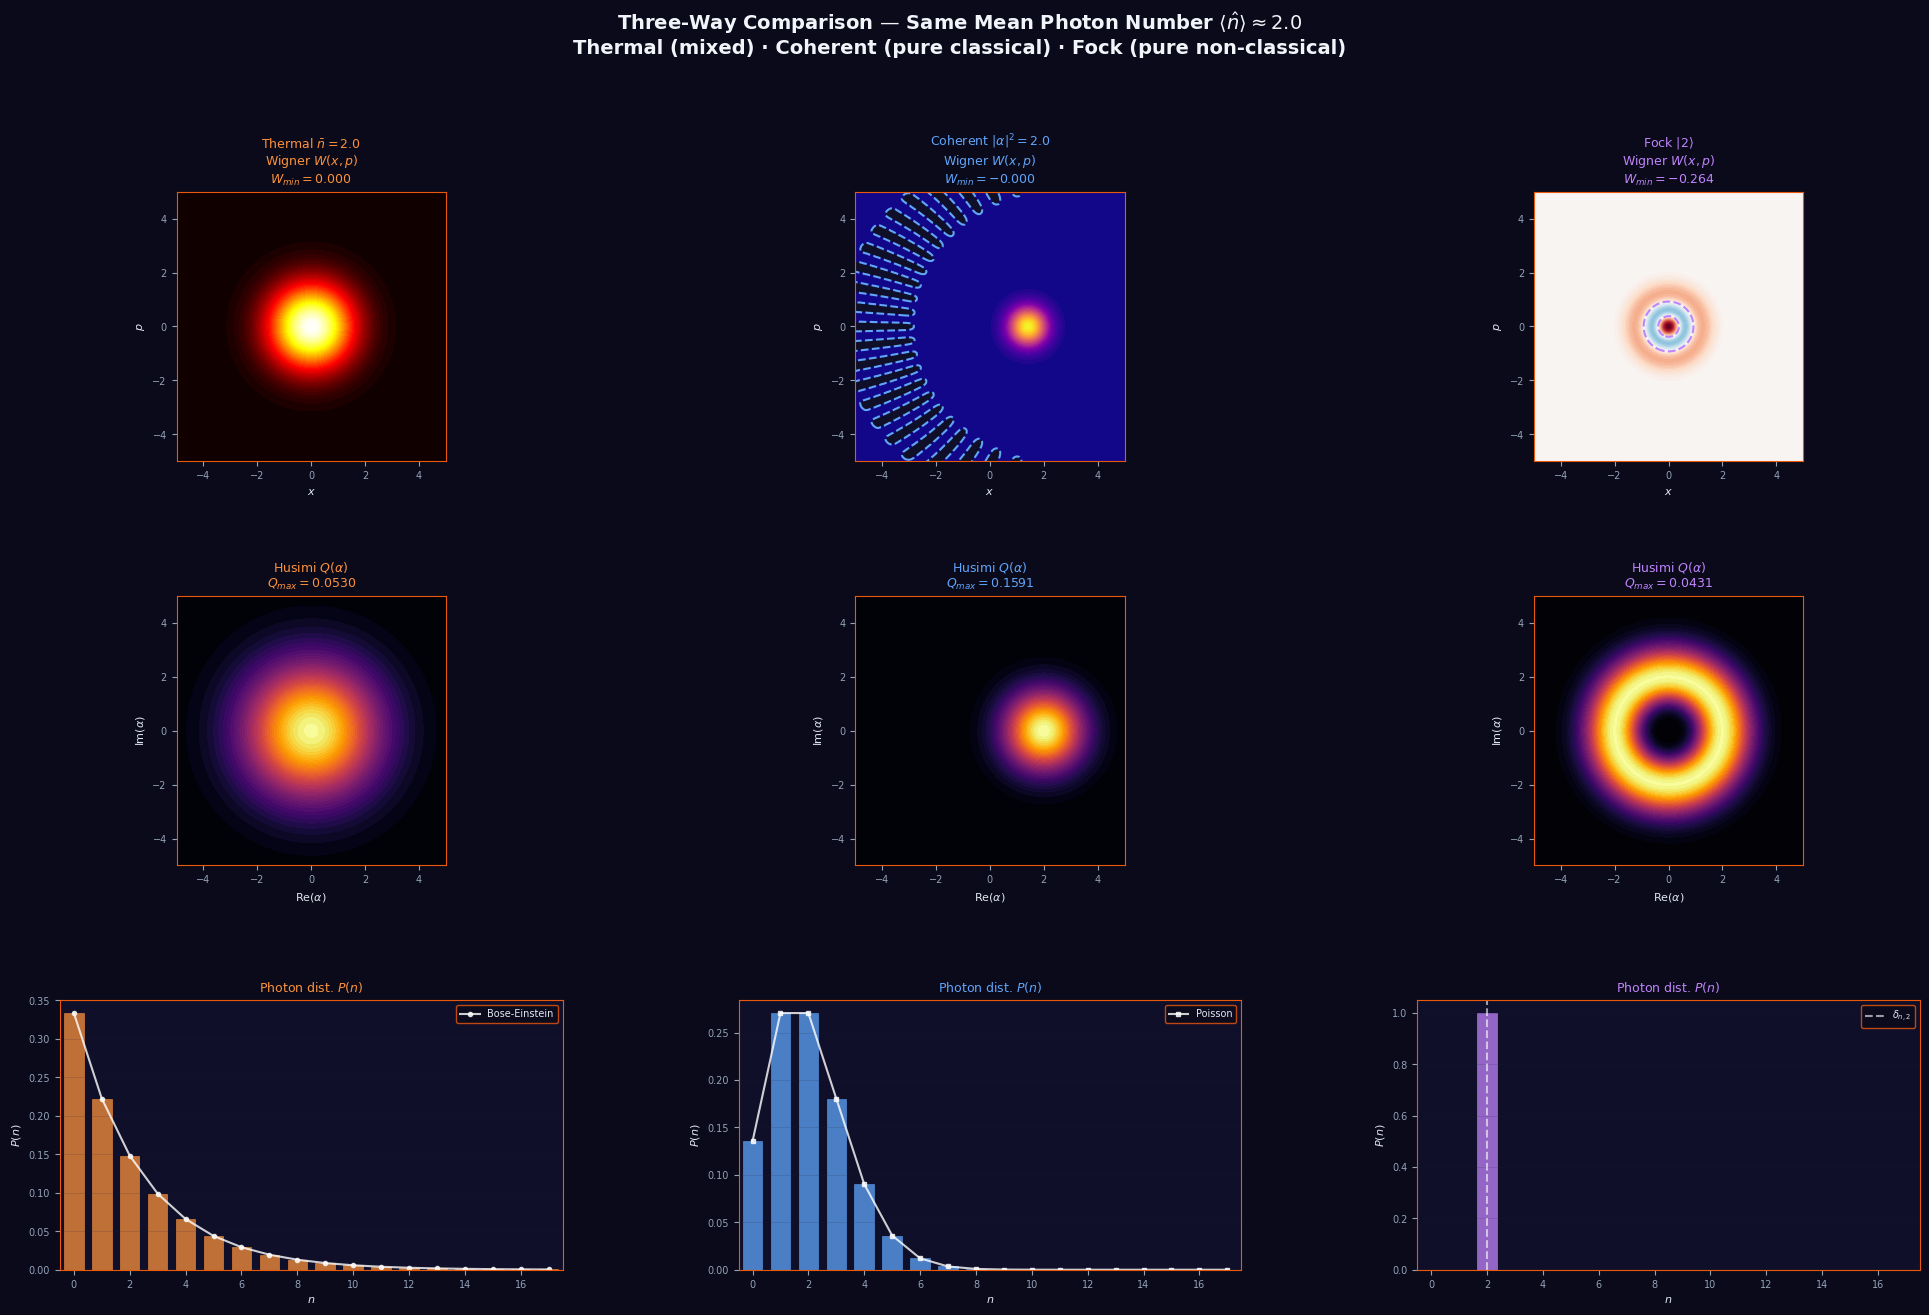

✅ Saved: fig14_three_state_comparison.png


In [20]:
# ============================================================
# CELL 18 — Three-Way State Comparison (same mean photon number)
# ============================================================
# All states at <n> ≈ 2 for fair comparison
# Thermal: nbar=2 | Coherent: |alpha|²=2 → alpha=√2
# Fock: |2>
# ============================================================

from qutip import coherent_dm

XVEC_C = np.linspace(-6, 6, 250)
NB_COMP = 2.0

rho_th  = make_thermal(NB_COMP, DIM)
rho_coh = coherent_dm(DIM, np.sqrt(NB_COMP))
rho_fock= ket2dm(basis(DIM, 2))

states_comp  = [rho_th, rho_coh, rho_fock]
labels_comp  = [rf'Thermal $\bar{{n}}={NB_COMP}$',
                rf'Coherent $|\alpha|^2={NB_COMP}$',
                r'Fock $|2\rangle$']
colors_comp  = [C['orange'], C['blue'], C['purple']]
cmaps_comp   = ['hot', 'plasma', 'magma']

fig = plt.figure(figsize=(24, 14))
fig.suptitle(
    f'Three-Way Comparison — Same Mean Photon Number $\\langle\\hat{{n}}\\rangle\\approx{NB_COMP}$\n'
    'Thermal (mixed) · Coherent (pure classical) · Fock (pure non-classical)',
    fontsize=14, color=C['white'], fontweight='bold', y=1.01
)

# 3 rows: W, Q, P(n)  ×  3 columns: thermal, coherent, fock
outer_gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.5, wspace=0.35)
row_titles = ['Wigner $W(x,p)$', r'Husimi $Q(\alpha)$', 'Photon dist. $P(n)$']

SHOW_C = 18
k_c    = np.arange(SHOW_C)

for col_i, (rho, lbl, col, cmap) in enumerate(zip(states_comp, labels_comp, colors_comp, cmaps_comp)):
    W = compute_wigner(rho, XVEC_C)
    Q = compute_husimi(rho, XVEC_C)
    probs = np.array([rho[k, k].real for k in range(SHOW_C)])

    # Row 0: Wigner
    ax_w = fig.add_subplot(outer_gs[0, col_i])
    wmax = max(abs(W.min()), abs(W.max()))
    if W.min() >= -1e-6:  # non-negative: use sequential
        ax_w.contourf(XVEC_C, XVEC_C, W, levels=50, cmap=cmap, vmin=0)
    else:                  # negative: use diverging
        norm_w = TwoSlopeNorm(vmin=-wmax, vcenter=0, vmax=wmax)
        ax_w.contourf(XVEC_C, XVEC_C, W, levels=50, cmap='RdBu_r', norm=norm_w)
    ax_w.contour(XVEC_C, XVEC_C, W, levels=[0],
                 colors=[col], lw=1.5, linestyles='--')
    ax_w.set_title(f'{lbl}\n{row_titles[0]}\n$W_{{min}}={W.min():.3f}$',
                   fontsize=9, color=col)
    ax_w.set_aspect('equal'); ax_w.set_xlim(-5, 5); ax_w.set_ylim(-5, 5)
    ax_w.set_xlabel('$x$', fontsize=8); ax_w.set_ylabel('$p$', fontsize=8)
    ax_w.tick_params(labelsize=7)

    # Row 1: Husimi Q
    ax_q = fig.add_subplot(outer_gs[1, col_i])
    ax_q.contourf(XVEC_C, XVEC_C, Q, levels=50, cmap='inferno')
    ax_q.set_title(f'{row_titles[1]}\n$Q_{{max}}={Q.max():.4f}$',
                   fontsize=9, color=col)
    ax_q.set_aspect('equal'); ax_q.set_xlim(-5, 5); ax_q.set_ylim(-5, 5)
    ax_q.set_xlabel(r'$\mathrm{Re}(\alpha)$', fontsize=8)
    ax_q.set_ylabel(r'$\mathrm{Im}(\alpha)$', fontsize=8)
    ax_q.tick_params(labelsize=7)

    # Row 2: Photon distribution
    ax_p = fig.add_subplot(outer_gs[2, col_i])
    ax_p.bar(k_c, probs, color=col, alpha=0.75, width=0.7,
             edgecolor=col, lw=0.5)
    if col_i == 0:  # thermal: overlay Bose-Einstein
        be = bose_einstein_pn(NB_COMP, SHOW_C)
        ax_p.plot(k_c, be, 'o-', color='white', ms=3, lw=1.5, alpha=0.8,
                  label='Bose-Einstein')
    elif col_i == 1:  # coherent: overlay Poisson
        po = poisson_pn(NB_COMP, SHOW_C)
        ax_p.plot(k_c, po, 's-', color='white', ms=3, lw=1.5, alpha=0.8,
                  label='Poisson')
    elif col_i == 2:  # Fock: delta at n=2
        ax_p.axvline(2, color='white', lw=1.5, ls='--', alpha=0.6,
                     label='$\\delta_{n,2}$')
    ax_p.set_title(row_titles[2], fontsize=9, color=col)
    ax_p.set_xlabel('$n$', fontsize=8); ax_p.set_ylabel('$P(n)$', fontsize=8)
    ax_p.set_xlim(-0.5, SHOW_C-0.5); ax_p.tick_params(labelsize=7)
    ax_p.grid(True, alpha=0.2, axis='y')
    ax_p.legend(fontsize=7)

plt.savefig(OUTPUT_DIR / 'fig14_three_state_comparison.png', dpi=200, bbox_inches='tight')
plt.show()
print('✅ Saved: fig14_three_state_comparison.png')

<a id='16'></a>
## 16. Interactive 3D Wigner Surface (Plotly)

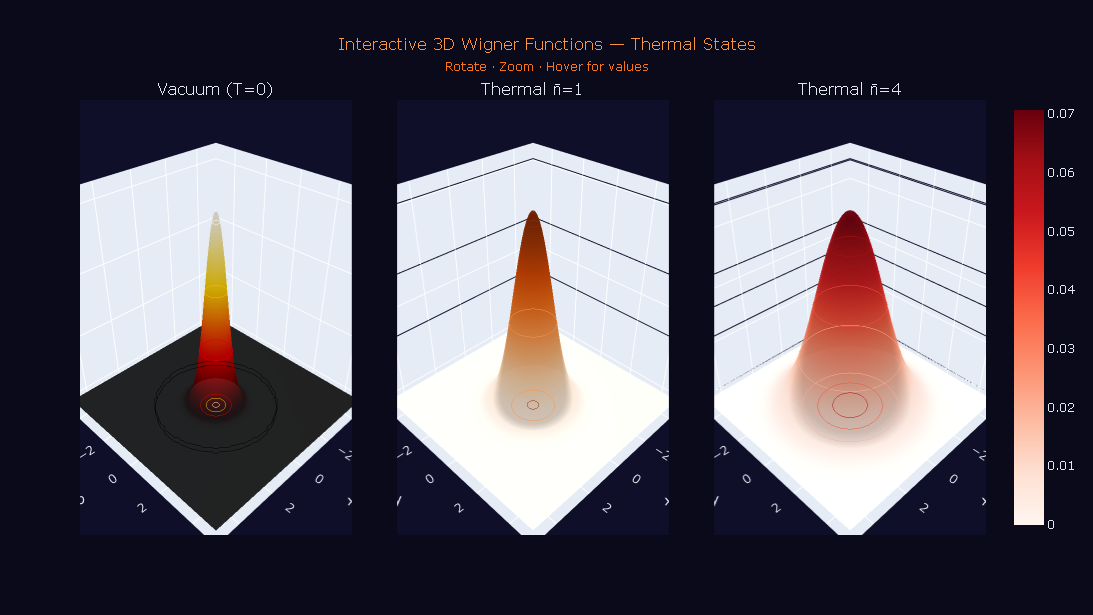

✅ Saved: fig15_wigner_3d_interactive.html


In [21]:
# ============================================================
# CELL 19 — Interactive 3D Wigner Surfaces (Plotly)
# ============================================================

XVEC_3D = np.linspace(-5, 5, 100)
XX3, YY3 = np.meshgrid(XVEC_3D, XVEC_3D)

nbars_3d   = [0.0, 1.0, 4.0]
labels_3d  = ['Vacuum (T=0)', 'Thermal n̄=1', 'Thermal n̄=4']

fig3d = make_subplots(
    rows=1, cols=3,
    subplot_titles=labels_3d,
    specs=[[{'type': 'surface'}]*3],
    horizontal_spacing=0.05
)

colorscales = ['Hot', 'Oranges', 'Reds']
for col_i, (nb, lbl, cs) in enumerate(zip(nbars_3d, labels_3d, colorscales), 1):
    W3 = compute_wigner(make_thermal(nb, DIM), XVEC_3D)
    fig3d.add_trace(
        go.Surface(
            x=XVEC_3D, y=XVEC_3D, z=W3,
            colorscale=cs, showscale=(col_i == 3),
            opacity=0.92,
            contours=dict(
                z=dict(show=True, usecolormap=True, highlightcolor='white',
                       project_z=True, width=1)
            ),
            name=lbl,
        ),
        row=1, col=col_i
    )

fig3d.update_layout(
    title=dict(
        text='Interactive 3D Wigner Functions — Thermal States'
             '<br><span style="font-size:12px;color:#f97316">'  
             'Rotate · Zoom · Hover for values</span>',
        x=0.5, font=dict(size=16, color='#fb923c')
    ),
    paper_bgcolor='#0a0a1a',
    font=dict(color='#e2e8f0'),
    height=600, width=1400,
    scene=dict(
        xaxis_title='x', yaxis_title='p', zaxis_title='W(x,p)',
        bgcolor='#0f0f2a',
    ),
    scene2=dict(bgcolor='#0f0f2a'),
    scene3=dict(bgcolor='#0f0f2a'),
)
fig3d.write_html(str(OUTPUT_DIR / 'fig15_wigner_3d_interactive.html'))
fig3d.show()
print('✅ Saved: fig15_wigner_3d_interactive.html')

<a id='17'></a>
## 17. Non-Classicality Dashboard

In [22]:
# ============================================================
# CELL 20 — Non-Classicality Witnesses Dashboard
# ============================================================
# Thermal states are CLASSICAL: P≥0, W≥0, MandelQ≥0
# This cell demonstrates all witnesses confirm classicality
# ============================================================

fig = plt.figure(figsize=(24, 15))
fig.suptitle('Non-Classicality Analysis — Thermal States Are Maximally Classical',
             fontsize=16, color=C['amber'], fontweight='bold', y=1.01)
gs = gridspec.GridSpec(2, 4, figure=fig, hspace=0.52, wspace=0.40)

nbars_c = np.linspace(0, 8, 400)

# ── 1: Wigner negativity volume = 0 for all thermal ──────
ax1 = fig.add_subplot(gs[0, 0])
neg_vols = [wigner_neg_volume(wigner_data[nb]['W'], XVEC) for nb in TH_NBARS]
ax1.bar(range(len(TH_NBARS)), neg_vols, color=TH_COLORS, alpha=0.85)
ax1.axhline(0, color=C['green'], lw=2, ls='--', label='Classical boundary')
ax1.set_xticks(range(len(TH_NBARS)))
ax1.set_xticklabels([f'$\\bar{{n}}={nb}$' for nb in TH_NBARS], rotation=30, fontsize=8)
ax1.set_ylabel(r'$\delta_W$', fontsize=10)
ax1.set_title('Wigner neg. volume = 0\n(classical states)', color=C['green'])
ax1.legend(fontsize=8); ax1.grid(True, alpha=0.2, axis='y')

# ── 2: Mandel Q vs n̄ ─────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
mq_ana = nbars_c   # Mandel Q = n̄ for thermal
ax2.plot(nbars_c, mq_ana, color=C['orange'], lw=2.5,
         label=r'$Q_M = \bar{n}$')
mq_pts = [th_metrics[nb]['mandel_Q'] for nb in TH_NBARS]
ax2.scatter(TH_NBARS, mq_pts, s=120, c=TH_COLORS, zorder=10, edgecolors='white')
ax2.axhline(0, color=C['green'], lw=1.5, ls='--',
            label='Q_M=0 (Poissonian)')
ax2.fill_between(nbars_c, 0, mq_ana, color=C['orange'], alpha=0.1)
ax2.set_xlabel(r'$\bar{n}$', fontsize=10); ax2.set_ylabel('$Q_M$', fontsize=10)
ax2.set_title('Mandel Q — super-Poissonian', color=C['amber'])
ax2.legend(fontsize=8); ax2.grid(True, alpha=0.3)

# ── 3: Symplectic eigenvalue vs n̄ ────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
nu_ana = nbars_c + 0.5
ax3.plot(nbars_c, nu_ana, color=C['red'], lw=2.5,
         label=r'$\nu = \bar{n}+\tfrac{1}{2}$')
nu_pts = [th_metrics[nb]['nu_symp'] for nb in TH_NBARS]
ax3.scatter(TH_NBARS, nu_pts, s=120, c=TH_COLORS, zorder=10, edgecolors='white')
ax3.axhline(0.5, color=C['green'], lw=1.5, ls='--', label='Heisenberg bound $\\nu=0.5$')
ax3.fill_between(nbars_c, 0.5, nu_ana, color=C['red'], alpha=0.1)
ax3.set_xlabel(r'$\bar{n}$', fontsize=10); ax3.set_ylabel(r'$\nu$', fontsize=10)
ax3.set_title('Symplectic eigenvalue', color=C['red'])
ax3.legend(fontsize=8); ax3.grid(True, alpha=0.3)

# ── 4: Mean photon number <n> = sinh²(r) comparison ─────
ax4 = fig.add_subplot(gs[0, 3])
ax4.plot(nbars_c, nbars_c, color=C['orange'], lw=2.5,
         label=r'Thermal: $\langle\hat{n}\rangle=\bar{n}$')
# Fock states for reference
fock_n = np.arange(0, 9)
ax4.scatter(fock_n, fock_n, s=100, color=C['purple'], zorder=10,
            edgecolors='white', label='Fock $|n\\rangle$', marker='D')
ax4.set_xlabel(r'$\bar{n}$', fontsize=10)
ax4.set_ylabel(r'$\langle\hat{n}\rangle$', fontsize=10)
ax4.set_title('Mean photon number', color=C['amber'])
ax4.legend(fontsize=8); ax4.grid(True, alpha=0.3)

# ── 5: P function positivity bar ─────────────────────────
ax5 = fig.add_subplot(gs[1, 0])
# All thermal P functions are positive → bar at 1
ax5.bar(range(len(TH_NBARS)), [1]*len(TH_NBARS),
        color=TH_COLORS, alpha=0.85)
ax5.set_xticks(range(len(TH_NBARS)))
ax5.set_xticklabels([f'$\\bar{{n}}={nb}$' for nb in TH_NBARS], rotation=30, fontsize=8)
ax5.set_ylim(0, 1.5); ax5.set_ylabel('P ≥ 0 (1=classical)', fontsize=9)
ax5.set_title('P function positivity\n(all thermal = 1)', color=C['green'])
ax5.axhline(1.0, color=C['green'], lw=1.5, ls='--', alpha=0.8)
ax5.grid(True, alpha=0.2, axis='y')

# ── 6: Variance comparison: thermal vs Poisson vs sub-P ──
ax6 = fig.add_subplot(gs[1, 1])
var_th   = nbars_c * (nbars_c + 1)
var_poi  = nbars_c
ax6.plot(nbars_c, var_th, color=C['orange'], lw=2.5,
         label=r'Thermal: $\bar{n}(\bar{n}+1)$')
ax6.plot(nbars_c, var_poi, color=C['cyan'], lw=2,
         ls='--', label=r'Poissonian: $\bar{n}$')
ax6.fill_between(nbars_c, var_poi, var_th, color=C['orange'], alpha=0.15,
                 label='Super-Poissonian excess')
ax6.set_xlabel(r'$\bar{n}$', fontsize=10); ax6.set_ylabel(r'$\mathrm{Var}(\hat{n})$', fontsize=10)
ax6.set_title('Photon number variance', color=C['amber'])
ax6.legend(fontsize=8); ax6.grid(True, alpha=0.3)

# ── 7: Entropy comparison: thermal vs pure ────────────────
ax7 = fig.add_subplot(gs[1, 2])
S_th_c = entropy_thermal_ana(nbars_c)
ax7.plot(nbars_c, S_th_c, color=C['red'], lw=2.5,
         label='Thermal entropy')
ax7.axhline(0, color=C['green'], lw=1.5, ls='--', alpha=0.8,
            label='Pure state S=0')
ax7.fill_between(nbars_c, 0, S_th_c, color=C['red'], alpha=0.12)
ax7.set_xlabel(r'$\bar{n}$', fontsize=10)
ax7.set_ylabel('$S_{vN}$ [nats]', fontsize=10)
ax7.set_title('von Neumann entropy', color=C['red'])
ax7.legend(fontsize=9); ax7.grid(True, alpha=0.3)

# ── 8: Summary classicality indicator ────────────────────
ax8 = fig.add_subplot(gs[1, 3])
indicators = ['$W\\geq 0$', '$P\\geq 0$', '$Q_M\\geq 0$', '$S_{vN}\\geq 0$']
values     = [1, 1, 1, 1]   # all 1 = all classical witnesses satisfied
colors_ind = [C['green'], C['green'], C['orange'], C['amber']]
bars = ax8.barh(indicators, values, color=colors_ind, alpha=0.85)
ax8.set_xlim(0, 1.5)
ax8.set_title('Classicality checklist\n(all ✓ for thermal)', color=C['green'])
for bar, val in zip(bars, values):
    ax8.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
             '✓ Classical', va='center', color=C['green'], fontweight='bold', fontsize=10)
ax8.set_xlabel('Satisfied = 1', fontsize=9)
ax8.grid(True, alpha=0.2, axis='x')

plt.savefig(OUTPUT_DIR / 'fig16_nonclassicality_dashboard.png', dpi=250, bbox_inches='tight')
plt.show()
print('✅ Saved: fig16_nonclassicality_dashboard.png')

ValueError: 
\nu = \bar{n}+\tfrac{1}{2}
              ^
ParseFatalException: Unknown symbol: \tfrac, found '\'  (at char 14), (line:1, col:15)

Error in callback <function _draw_all_if_interactive at 0x14f549616dd0> (for post_execute), with arguments args (),kwargs {}:


ValueError: 
\nu = \bar{n}+\tfrac{1}{2}
              ^
ParseFatalException: Unknown symbol: \tfrac, found '\'  (at char 14), (line:1, col:15)

ValueError: 
\nu = \bar{n}+\tfrac{1}{2}
              ^
ParseFatalException: Unknown symbol: \tfrac, found '\'  (at char 14), (line:1, col:15)

<Figure size 2400x1500 with 8 Axes>

<a id='18'></a>
## 18. Master Comparison Figure

In [ ]:
# ============================================================
# CELL 21 — Master Comparison: All Representations
# ============================================================
# Columns: rho | W(x,p) | Q(α) | P(n)
# Rows: each thermal state
# ============================================================

XVEC_M  = np.linspace(-7, 7, 120)
XVEC_QM = np.linspace(-6, 6, 80)

fig = plt.figure(figsize=(26, 5.5 * len(TH_NBARS)))
fig.suptitle(
    'Complete Phase Space Analysis — All Thermal States\n'
    r'Density Matrix · Wigner $W(x,p)$ · Husimi $Q(\alpha)$ · Photon Distribution $P(n)$',
    fontsize=15, color=C['orange'], fontweight='bold', y=1.005
)

outer_gs = gridspec.GridSpec(len(TH_NBARS), 4, figure=fig, hspace=0.55, wspace=0.35)

DISP_M = 14
SHOW_M = 18
k_m    = np.arange(SHOW_M)

for row_i, nb in enumerate(TH_NBARS):
    rho = th_states[nb]
    col = TH_COLORS[row_i]
    m   = th_metrics[nb]

    # ── Col 0: Density matrix ─────────────────────────────
    ax0 = fig.add_subplot(outer_gs[row_i, 0])
    mat = rho.full()[:DISP_M, :DISP_M].real
    vmax = max(mat.max(), 1e-9)
    vmin = min(mat.min(), -1e-9)
    norm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)
    ax0.imshow(mat, cmap='RdBu_r', norm=norm, aspect='equal')
    ax0.set_title(f'{TH_LABELS[row_i]}\n$\\hat{{\\rho}}$ (Re)',
                  fontsize=9, color=col)
    ax0.set_xlabel('$m$', fontsize=7); ax0.set_ylabel('$n$', fontsize=7)
    ax0.tick_params(labelsize=6)

    # ── Col 1: Wigner ─────────────────────────────────────
    ax1 = fig.add_subplot(outer_gs[row_i, 1])
    W   = compute_wigner(rho, XVEC_M)
    ax1.contourf(XVEC_M, XVEC_M, W, levels=40, cmap='hot', vmin=0)
    # Thermal 1σ circle
    theta_ = np.linspace(0, 2*np.pi, 200)
    r_th = np.sqrt(2*nb + 1)
    ax1.plot(r_th*np.cos(theta_), r_th*np.sin(theta_), '--', color=col, lw=1.5, alpha=0.7)
    ax1.plot(np.cos(theta_), np.sin(theta_), ':', color=C['cyan'], lw=0.8, alpha=0.5)
    ax1.set_title(f'$W(x,p)$, $W_{{max}}={W.max():.4f}$', fontsize=9, color=col)
    ax1.set_xlabel('$x$', fontsize=7); ax1.set_ylabel('$p$', fontsize=7)
    ax1.set_aspect('equal'); ax1.tick_params(labelsize=6)
    ax1.set_xlim(-7, 7); ax1.set_ylim(-7, 7)

    # ── Col 2: Husimi Q ───────────────────────────────────
    ax2 = fig.add_subplot(outer_gs[row_i, 2])
    Q   = compute_husimi(rho, XVEC_QM)
    ax2.contourf(XVEC_QM, XVEC_QM, Q, levels=40, cmap='inferno')
    ax2.set_title(f'$Q(\\alpha)$, $Q_{{max}}={Q.max():.5f}$', fontsize=9, color=col)
    ax2.set_xlabel(r'$\mathrm{Re}(\alpha)$', fontsize=7)
    ax2.set_ylabel(r'$\mathrm{Im}(\alpha)$', fontsize=7)
    ax2.set_aspect('equal'); ax2.tick_params(labelsize=6)
    ax2.set_xlim(-6, 6); ax2.set_ylim(-6, 6)

    # ── Col 3: Photon distribution ────────────────────────
    ax3    = fig.add_subplot(outer_gs[row_i, 3])
    probs  = np.array([rho[k, k].real for k in range(SHOW_M)])
    probs_be = bose_einstein_pn(nb, SHOW_M)
    ax3.bar(k_m, probs, color=col, alpha=0.65, width=0.7)
    ax3.plot(k_m, probs_be, 'o-', color='white', ms=3, lw=1.2, alpha=0.8)
    ax3.set_title(f'$P(n)$,  $Q_M={m["mandel_Q"]:.3f}$,  '
                  f'$S={m["entropy_nats"]:.3f}$',
                  fontsize=9, color=col)
    ax3.set_xlabel('$n$', fontsize=7); ax3.set_ylabel('$P(n)$', fontsize=7)
    ax3.set_xlim(-0.5, SHOW_M-0.5); ax3.tick_params(labelsize=6)
    ax3.grid(True, alpha=0.2, axis='y')

    # Row label on the left
    fig.text(0.002, 1 - (row_i + 0.5)/len(TH_NBARS),
             TH_LABELS[row_i], fontsize=10, color=col,
             va='center', ha='left', fontweight='bold')

plt.savefig(OUTPUT_DIR / 'fig17_master_comparison.png', dpi=200, bbox_inches='tight')
plt.show()
print('✅ Saved: fig17_master_comparison.png')

<a id='19'></a>
## 19. Summary Table & Export

In [ ]:
# ============================================================
# CELL 22 — Summary Table, Validation & Export
# ============================================================

rows = []
for idx, nb in enumerate(TH_NBARS):
    m  = th_metrics[nb]
    wd = wigner_data[nb]
    rows.append({
        'Label'         : TH_LABELS[idx],
        'nbar'          : nb,
        'mean_n'        : m['mean_n'],
        'Var_n'         : m['var_n'],
        'Var_n_ana'     : m['var_n_ana'],
        'Purity_num'    : m['purity'],
        'Purity_ana'    : m['purity_ana'],
        'S_vN_nats'     : m['entropy_nats'],
        'S_vN_bits'     : m['entropy_bits'],
        'S_vN_ana'      : m['entropy_ana'],
        'MandelQ_num'   : m['mandel_Q'],
        'MandelQ_ana'   : m['mandel_ana'],
        'delta_x'       : m['delta_x'],
        'delta_p'       : m['delta_p'],
        'DxDp'          : m['heis_prod'],
        'nu_symp_num'   : m['nu_symp'],
        'nu_symp_ana'   : m['nu_ana'],
        'W_max_num'     : round(wd['W_max'], 6),
        'W_max_ana'     : round(wd['W_peak_ana'], 6),
        'W_min'         : round(wd['W_min'], 6),
        'neg_vol'       : round(wd['neg_vol'], 6),
        'Classical'     : 'YES',
    })

df = pd.DataFrame(rows).set_index('Label')
print('='*120)
print('NOTEBOOK 04 — THERMAL STATES — COMPLETE SUMMARY TABLE')
print('='*120)
print(df.to_string())

# ── Validation block ──────────────────────────────────────
print('\n' + '='*60)
print('VALIDATION CHECKS (all should be < 1e-3)')
print('='*60)
for nb in TH_NBARS:
    m = th_metrics[nb]
    err_var = abs(m['var_n'] - m['var_n_ana'])
    err_pur = abs(m['purity'] - m['purity_ana'])
    err_nu  = abs(m['nu_symp'] - m['nu_ana'])
    err_ent = abs(m['entropy_nats'] - m['entropy_ana'])
    status = '✅' if max(err_var, err_pur, err_nu) < 5e-3 else '⚠️'
    print(f'{status} nbar={nb:.1f} | dVar={err_var:.2e} '
          f'dPurity={err_pur:.2e} dNu={err_nu:.2e} dS={err_ent:.2e}')

# ── Export ────────────────────────────────────────────────
df.to_csv(OUTPUT_DIR / 'summary_thermal_states.csv')
with open(OUTPUT_DIR / 'summary_thermal_states.json', 'w') as f:
    json.dump(rows, f, indent=2, default=str)
print('\n✅ Saved: summary_thermal_states.csv & .json')

In [ ]:
# ============================================================
# CELL 23 — Interactive Plotly Summary Table
# ============================================================

fig_tbl = go.Figure(data=[go.Table(
    header=dict(
        values=['<b>State</b>', '<b>n̄</b>', '<b>Purity</b>', '<b>S [nats]</b>',
                '<b>Var(n)</b>', '<b>Mandel Q</b>', '<b>ν_symp</b>',
                '<b>Δx=Δp</b>', '<b>W_max</b>', '<b>Classical</b>'],
        fill_color='#1e1e3f',
        font=dict(color='#fb923c', size=12),
        align='center', height=40,
        line_color='#ea580c',
    ),
    cells=dict(
        values=[
            [r['Label'] for r in rows],
            [r['nbar']           for r in rows],
            [f"{r['Purity_num']:.5f}" for r in rows],
            [f"{r['S_vN_nats']:.5f}"  for r in rows],
            [f"{r['Var_n']:.4f}"      for r in rows],
            [f"{r['MandelQ_num']:.4f}" for r in rows],
            [f"{r['nu_symp_num']:.4f}" for r in rows],
            [f"{r['delta_x']:.5f}"    for r in rows],
            [f"{r['W_max_num']:.5f}"  for r in rows],
            [r['Classical']           for r in rows],
        ],
        fill_color=['#0a0a1a', '#0f0f2a'] * 5,
        font=dict(color='#e2e8f0', size=11),
        align='center', height=32,
        line_color='#1e1e3f',
    )
)])

fig_tbl.update_layout(
    title=dict(
        text='Thermal State Quantum Metrics — Interactive Summary',
        font=dict(size=16, color='#fb923c'), x=0.5
    ),
    paper_bgcolor='#0a0a1a',
    height=400, width=1200,
)
fig_tbl.write_html(str(OUTPUT_DIR / 'fig18_summary_table.html'))
fig_tbl.show()
print('✅ Saved: fig18_summary_table.html')

<a id='20'></a>
## 20. Final Output Listing

In [ ]:
# ============================================================
# CELL 24 — Final Output Listing
# ============================================================

print('='*70)
print('   NOTEBOOK 04 — THERMAL STATES — COMPLETE')
print('='*70)

files = sorted(OUTPUT_DIR.glob('*'))
print(f'\n  Output directory: {OUTPUT_DIR.resolve()}')
print(f'  {len(files)} files generated:\n')
print(f'  {"Filename":<55} {"Size":>10}')
print(f'  {"-"*55} {"-"*10}')
for f in files:
    kb = f.stat().st_size / 1024
    tag = '📊' if f.suffix == '.png' else ('🌐' if f.suffix == '.html' else '📋')
    print(f'  {tag} {f.name:<52} {kb:>8.1f} KB')
total_mb = sum(f.stat().st_size for f in files) / 1024**2
print(f'\n  Total: {len(files)} files, {total_mb:.2f} MB')
print('='*70)
print('\n✅ Notebook 04 complete. Ready for Notebook 05 — Cat States')

<a id='21'></a>

---
## References

1. Mandel, L. & Wolf, E. *Optical Coherence and Quantum Optics*. Cambridge University Press, 1995.
2. Walls, D. F. & Milburn, G. J. *Quantum Optics*. 2nd ed., Springer, 2008.
3. Barnett, S. M. & Radmore, P. M. *Methods in Theoretical Quantum Optics*. Oxford University Press, 1997.
4. Serafini, A. *Quantum Continuous Variables*. CRC Press, 2017.
5. Weedbrook, C. et al. *Gaussian quantum information*. Rev. Mod. Phys. **84**, 621 (2012).
6. Adesso, G. & Illuminati, F. *Entanglement in continuous-variable systems*. J. Phys. A **40**, 7821 (2007).
7. Paris, M. G. A. *The modern tools of quantum mechanics*. Eur. Phys. J. Special Topics **203**, 61 (2012).

---

<div style="background:#1a0a0a;padding:24px;border-radius:12px;border-left:4px solid #fb923c">
<h3 style="color:#fb923c">📌 Key Takeaways — Thermal States</h3>
<ul style="color:#e2e8f0;line-height:2.2">
<li>Thermal states are <strong>diagonal in the Fock basis</strong> — no quantum coherences, maximally classical mixed states</li>
<li>Photon statistics follow the <strong>Bose-Einstein (geometric) distribution</strong> — super-Poissonian ($Q_M = \bar{n} > 0$)</li>
<li>Wigner and P functions are <strong>always non-negative</strong> — thermal states satisfy all classicality criteria</li>
<li>Covariance matrix is <strong>isotropic</strong>: $\boldsymbol{\sigma}=(\bar{n}+\tfrac{1}{2})\mathbf{I}_2$ — no preferred quadrature</li>
<li>Purity $\mathrm{Tr}(\hat{\rho}^2) = 1/(2\bar{n}+1)$ decreases monotonically with temperature</li>
<li>von Neumann entropy $S = (\bar{n}+1)\ln(\bar{n}+1) - \bar{n}\ln\bar{n}$ increases with $T$</li>
<li>Symplectic eigenvalue $\nu = \bar{n}+\tfrac{1}{2} \geq \tfrac{1}{2}$ — saturates Heisenberg only at $T=0$ (vacuum)</li>
<li>Industrial relevance: <strong>noise modeling, CV-QKD security, quantum thermometry, open systems</strong></li>
</ul>
</div>